# Libs

In [1]:
import os
import re
import random

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import tqdm

In [4]:
from transformers import AutoTokenizer
from transformers import AutoModelForCausalLM
from transformers import TrainingArguments, Trainer
from transformers import pipeline
from transformers import DataCollatorWithPadding

from transformers import PreTrainedTokenizerFast
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.pre_tokenizers import Whitespace

import torch
from datasets import Dataset, DatasetDict, load_dataset

In [5]:
from huggingface_hub import login
from huggingface_hub import whoami

from kaggle_secrets import UserSecretsClient
import kagglehub

In [6]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

In [7]:
!pip install onnxruntime-gpu

import onnxruntime as ort

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 7.3 MB/s eta 0:00:00


# Constants

In [8]:
OUT_DIR = "gpt-faces-generator"
os.makedirs(OUT_DIR,exist_ok=True)

In [9]:
MODEL_NAME = 'openai-community/gpt2'
DATASET_NAME = 'suayptalha/Poetry-Foundation-Poems'

In [10]:
VAL_SPLIT_RATIO = 0.3

In [11]:
MAX_LEN = 300

# Tokens

In [12]:
TOKEN_START_FACE = "<START_FACE>"
TOKEN_START_GENERATION = "<START_GENERATION>"
TOKEN_END_GENERATION = "<END_GENERATION>"

In [13]:
# Selected features from CelebFace original dataset

FACE_ATTRIBUTES = {
    "Attractive":       ["<NOT_ATTRACTIVE>", "<ATTRACTIVE>"],
    "Bags_Under_Eyes":  ["<NO_EYE_BAGS>", "<EYE_BAGS>"],
    "Bald":             ["<NOT_BALD>", "<BALD>"],
    "Bangs":            ["<NO_BANGS>", "<BANGS>"],
    "Big_Lips":         ["<SMALL_LIPS>", "<BIG_LIPS>"],
    "Big_Nose":         ["<SMALL_NOSE>", "<BIG_NOSE>"],
    "Black_Hair":       ["<NOT_BLACK_HAIR>", "<BLACK_HAIR>"],
    "Blond_Hair":       ["<NOT_BLOND_HAIR>", "<BLOND_HAIR>"],
    "Brown_Hair":       ["<NOT_BROWN_HAIR>", "<BROWN_HAIR>"],
    "Blurry":           ["<CLEAR_IMAGE>", "<BLURRY_IMAGE>"],
    "Eyeglasses":       ["<NO_GLASSES>", "<GLASSES>"],
    "Gray_Hair":        ["<NO_GRAY_HAIR>", "<GRAY_HAIR>"],
    "Heavy_Makeup":     ["<LIGHT_MAKEUP>", "<HEAVY_MAKEUP>"],
    "High_Cheekbones":  ["<LOW_CHEEKBONES>", "<HIGH_CHEEKBONES>"],
    "Male":             ["<FEMALE>", "<MALE>"],
    "Mouth_Slightly_Open": ["<MOUTH_CLOSED>", "<MOUTH_OPEN>"],
    "Mustache":         ["<NO_MUSTACHE>", "<MUSTACHE>"],
    "Narrow_Eyes":      ["<WIDE_EYES>", "<NARROW_EYES>"],
    "No_Beard":         ["<BEARD>", "<NO_BEARD>"],
    "Oval_Face":        ["<NON_OVAL_FACE>", "<OVAL_FACE>"],
    "Pointy_Nose":      ["<ROUND_NOSE>", "<POINTY_NOSE>"],
    "Smiling":          ["<NOT_SMILING>", "<SMILING>"],
    "Straight_Hair":    ["<NOT_STRAIGHT_HAIR>", "<STRAIGHT_HAIR>"],
    "Wavy_Hair":        ["<NOT_WAVY_HAIR>", "<WAVY_HAIR>"],
    "Wearing_Lipstick": ["<NO_LIPSTICK>", "<LIPSTICK>"],
    "Young":            ["<OLD>", "<YOUNG>"]
}


# Auth

In [14]:
login(token=UserSecretsClient().get_secret("HF") )

In [15]:
print("Logged in as:", whoami()['name'])

Logged in as: yosef-samy019


In [16]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # only use first GPU

# Dataset: CelebFace

In [17]:
ds_path = kagglehub.dataset_download("youssef019/celebfaces-vq-vae-codes")

print("Path to dataset files:", ds_path)
print(os.listdir(ds_path))

Path to dataset files: /kaggle/input/datasets/youssef019/celebfaces-vq-vae-codes
['images_codes.csv']


In [18]:
img_codes_df = pd.read_csv(os.path.join(ds_path, "images_codes.csv"))

In [19]:
img_codes_df.head()

,image_id,code_000,code_001,code_002,code_003,code_004,code_005,code_006,code_007,code_008,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,144,273,273,146,273,273,273,101,244,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,192,323,43,237,392,29,25,263,39,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,375,421,83,103,393,244,44,360,360,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,296,236,96,208,282,27,417,353,166,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,92,484,306,419,191,138,38,106,45,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


# VQ-VAE and CodeBook

In [20]:
# Download latest version
model_path = kagglehub.model_download("youssef019/vq-vae-celebfaces-encoder-decoder/onnx/v1")

In [21]:
encoder_path = os.path.join(model_path, 'vq_vae_cache', 'deployment', 'celeb_face_vq_vae_encoder.onnx')
decoder_path = os.path.join(model_path, 'vq_vae_cache', 'deployment', 'celeb_face_vq_vae_decoder.onnx')

codeBook_path = os.path.join(model_path, 'vq_vae_cache', 'deployment', 'celeb_face_vq_vae_codebook.csv')

## CodeBook

In [22]:
class CodeBook:
    def __init__(self, codeBook_path):
        self.codeBook = pd.read_csv(codeBook_path)
        self.embedding_mat = self.codeBook.iloc[:, 1:].values.astype(np.float32)

        print('-' * 30)
        print("Path:", codeBook_path)
        print("Embedding Mat Shape:", self.embedding_mat.shape)
        print('-' * 30)

    def get_n_tokens(self):
        return self.embedding_mat.shape[0]

    def embedding_mat_2_codes(self, x):
      """
      x: (num_tokens, embedding_dim)
      returns: (num_tokens,) -> indices of nearest embeddings
      """

      x = x.astype(np.float32)
      codebook = self.embedding_mat

      # L2 distance
      x_sq = np.sum(x**2, axis=1, keepdims=True)
      e_sq = np.sum(codebook**2, axis=1)
      cross = np.dot(x, codebook.T)

      distances = x_sq + e_sq - 2 * cross

      indices = np.argmin(distances, axis=1)

      return indices

    def codes_2_embedding_mat(self, codes):
      """
      codes: (num_tokens,) -> indices of nearest embeddings
      returns: (num_tokens, embedding_dim)
      """

      return self.embedding_mat[codes]

In [23]:
codeBook = CodeBook(codeBook_path)

------------------------------
Path: /kaggle/input/models/youssef019/vq-vae-celebfaces-encoder-decoder/onnx/v1/1/vq_vae_cache/deployment/celeb_face_vq_vae_codebook.csv
Embedding Mat Shape: (512, 1024)
------------------------------


In [24]:
codeBook.get_n_tokens()

512

## ONNX Load

In [25]:
class ModelEncapsule:
    def __init__(self, model_path):
        self.sess = ort.InferenceSession(model_path)

        self.input_name = self.sess.get_inputs()[0].name
        self.input_shape = self.sess.get_inputs()[0].shape
        self.input_type = self.sess.get_inputs()[0].type
        self.output_name = self.sess.get_outputs()[0].name
        self.output_shape = self.sess.get_outputs()[0].shape
        self.output_type = self.sess.get_outputs()[0].type

        print('-' * 30)
        print("Path:", model_path)
        print("Input Name:", self.input_name)
        print("Input Shape:", self.input_shape)
        print("Input Type:", self.input_type)
        print("Output Name:", self.output_name)
        print("Output Shape:", self.output_shape)
        print("Output Type:", self.output_type)
        print('-' * 30)

    def predict(self, x):
        return self.sess.run([self.output_name], {self.input_name: x})[0]

In [26]:
encoder_model = ModelEncapsule(encoder_path)
decoder_model = ModelEncapsule(decoder_path)

------------------------------
Path: /kaggle/input/models/youssef019/vq-vae-celebfaces-encoder-decoder/onnx/v1/1/vq_vae_cache/deployment/celeb_face_vq_vae_encoder.onnx
Input Name: input
Input Shape: ['unk__272', 128, 128, 3]
Input Type: tensor(float)
Output Name: reshape_12
Output Shape: ['unk__273', 256, 1024]
Output Type: tensor(float)
------------------------------
------------------------------
Path: /kaggle/input/models/youssef019/vq-vae-celebfaces-encoder-decoder/onnx/v1/1/vq_vae_cache/deployment/celeb_face_vq_vae_decoder.onnx
Input Name: input
Input Shape: ['unk__638', 256, 1024]
Input Type: tensor(float)
Output Name: conv2d_69
Output Shape: ['unk__639', 128, 128, 3]
Output Type: tensor(float)
------------------------------


# Dataset Preparing

In [27]:
img_codes_dataset = []

In [28]:
for idx in tqdm.tqdm(range( len(img_codes_df) )):
    face_tokens = []
    codes_tokens = []

    record = img_codes_df.iloc[idx, :]

    # Load face tokens
    for attr in FACE_ATTRIBUTES:
        record_val_idx = 1 if int(record[attr]) > 0 else 0
        record_val = FACE_ATTRIBUTES[attr][record_val_idx]

        face_tokens.append( record_val )

    # Shuffle face tokens
    random.shuffle(face_tokens)

    # Read image tokens
    for i in range(256): # The encoder produces 256 tokens per 1 image
      token_idx = record[f'code_{i:03d}']
      codes_tokens.append(f'<CODE_{token_idx:03d}>')

    img_codes_dataset.append(
        " ".join(
            [TOKEN_START_FACE] +
            face_tokens +
            [TOKEN_START_GENERATION] +
            codes_tokens +
            [TOKEN_END_GENERATION]
        )
    )

100%|██████████| 202599/202599 [02:46<00:00, 1217.79it/s]


In [29]:
len(img_codes_dataset)

202599

In [30]:
img_codes_dataset[0]

'<START_FACE> <ATTRACTIVE> <BROWN_HAIR> <NOT_BALD> <HIGH_CHEEKBONES> <STRAIGHT_HAIR> <FEMALE> <LIPSTICK> <MOUTH_OPEN> <NOT_BLACK_HAIR> <HEAVY_MAKEUP> <NO_BANGS> <NO_EYE_BAGS> <WIDE_EYES> <NO_GRAY_HAIR> <NON_OVAL_FACE> <CLEAR_IMAGE> <NO_BEARD> <SMALL_NOSE> <NO_MUSTACHE> <SMALL_LIPS> <NO_GLASSES> <YOUNG> <SMILING> <NOT_BLOND_HAIR> <POINTY_NOSE> <NOT_WAVY_HAIR> <START_GENERATION> <CODE_144> <CODE_273> <CODE_273> <CODE_146> <CODE_273> <CODE_273> <CODE_273> <CODE_101> <CODE_244> <CODE_123> <CODE_438> <CODE_246> <CODE_400> <CODE_468> <CODE_181> <CODE_301> <CODE_146> <CODE_206> <CODE_273> <CODE_273> <CODE_273> <CODE_206> <CODE_328> <CODE_243> <CODE_007> <CODE_459> <CODE_410> <CODE_037> <CODE_334> <CODE_408> <CODE_497> <CODE_215> <CODE_273> <CODE_273> <CODE_273> <CODE_206> <CODE_382> <CODE_034> <CODE_191> <CODE_443> <CODE_052> <CODE_353> <CODE_413> <CODE_163> <CODE_377> <CODE_322> <CODE_196> <CODE_034> <CODE_273> <CODE_273> <CODE_382> <CODE_444> <CODE_388> <CODE_018> <CODE_469> <CODE_090> <COD

In [31]:
print("N Tokens:", len(str(img_codes_dataset[0]).split(' ')))

N Tokens: 285


# DS Splitting

In [32]:
clean_txt_train, clean_txt_val = train_test_split(
    img_codes_dataset,
    test_size=VAL_SPLIT_RATIO,
    random_state=42
)

In [33]:
print("Len Train:", len(clean_txt_train))
print("Len Val:  ", len(clean_txt_val))

Len Train: 141819
Len Val:   60780


In [34]:
train_dataset = Dataset.from_dict({
    "text": clean_txt_train
})

eval_dataset = Dataset.from_dict({
    "text": clean_txt_val
})

dataset = DatasetDict({
    "train": train_dataset,
    "validation": eval_dataset
})

In [35]:
print(train_dataset)
print()
print(eval_dataset)
print()
print(dataset)

Dataset({
    features: ['text'],
    num_rows: 141819
})

Dataset({
    features: ['text'],
    num_rows: 60780
})

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 141819
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 60780
    })
})


# Model

## Tokenizer

In [36]:
TOKENS_VOCAB_LIST = ['<BOS>', '<EOS>', '<UNK>']
TOKENS_VOCAB_LIST += [TOKEN_START_FACE, TOKEN_START_GENERATION, TOKEN_END_GENERATION]

for attr in FACE_ATTRIBUTES:
    TOKENS_VOCAB_LIST += FACE_ATTRIBUTES[attr]

for i in range(codeBook.get_n_tokens()):
    TOKENS_VOCAB_LIST.append(f'<CODE_{i:03d}>')

In [37]:
print(*TOKENS_VOCAB_LIST, sep='\t')
print("Len Tokens:", len(TOKENS_VOCAB_LIST))

<BOS>	<EOS>	<UNK>	<START_FACE>	<START_GENERATION>	<END_GENERATION>	<NOT_ATTRACTIVE>	<ATTRACTIVE>	<NO_EYE_BAGS>	<EYE_BAGS>	<NOT_BALD>	<BALD>	<NO_BANGS>	<BANGS>	<SMALL_LIPS>	<BIG_LIPS>	<SMALL_NOSE>	<BIG_NOSE>	<NOT_BLACK_HAIR>	<BLACK_HAIR>	<NOT_BLOND_HAIR>	<BLOND_HAIR>	<NOT_BROWN_HAIR>	<BROWN_HAIR>	<CLEAR_IMAGE>	<BLURRY_IMAGE>	<NO_GLASSES>	<GLASSES>	<NO_GRAY_HAIR>	<GRAY_HAIR>	<LIGHT_MAKEUP>	<HEAVY_MAKEUP>	<LOW_CHEEKBONES>	<HIGH_CHEEKBONES>	<FEMALE>	<MALE>	<MOUTH_CLOSED>	<MOUTH_OPEN>	<NO_MUSTACHE>	<MUSTACHE>	<WIDE_EYES>	<NARROW_EYES>	<BEARD>	<NO_BEARD>	<NON_OVAL_FACE>	<OVAL_FACE>	<ROUND_NOSE>	<POINTY_NOSE>	<NOT_SMILING>	<SMILING>	<NOT_STRAIGHT_HAIR>	<STRAIGHT_HAIR>	<NOT_WAVY_HAIR>	<WAVY_HAIR>	<NO_LIPSTICK>	<LIPSTICK>	<OLD>	<YOUNG>	<CODE_000>	<CODE_001>	<CODE_002>	<CODE_003>	<CODE_004>	<CODE_005>	<CODE_006>	<CODE_007>	<CODE_008>	<CODE_009>	<CODE_010>	<CODE_011>	<CODE_012>	<CODE_013>	<CODE_014>	<CODE_015>	<CODE_016>	<CODE_017>	<CODE_018>	<CODE_019>	<CODE_020>	<CODE_021>	<CODE_022>	<CODE_023>

In [38]:
TOKENS_VOCAB_DICT = {token: idx for idx, token in enumerate(TOKENS_VOCAB_LIST)}

In [39]:
backend_tokenizer = Tokenizer(WordLevel(vocab=TOKENS_VOCAB_DICT, unk_token="<UNK>"))
backend_tokenizer.pre_tokenizer = Whitespace()

In [40]:
tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=backend_tokenizer,
    bos_token="<BOS>",
    eos_token="<EOS>",
    unk_token="<UNK>",
)

tokenizer.pad_token = tokenizer.eos_token

In [41]:
tokenizer.add_special_tokens({
    "additional_special_tokens": TOKENS_VOCAB_LIST
})

567

In [42]:
print("<START_FACE>" in TOKENS_VOCAB_DICT)

True


## Test Tokenizer

In [43]:
temp_prompt = clean_txt_train[0]
print("Original:", temp_prompt)

temp_tokens = tokenizer.encode(temp_prompt)
print("Tokens:", temp_tokens)

temp_decoded = tokenizer.decode(temp_tokens)
print("Decoded:", temp_decoded)

print("Match:", temp_prompt == temp_decoded)

Original: <START_FACE> <MOUTH_CLOSED> <NO_EYE_BAGS> <NON_OVAL_FACE> <NO_GLASSES> <LIPSTICK> <ATTRACTIVE> <NO_BEARD> <SMALL_NOSE> <WIDE_EYES> <YOUNG> <POINTY_NOSE> <LIGHT_MAKEUP> <NO_GRAY_HAIR> <NOT_BLOND_HAIR> <BROWN_HAIR> <NOT_BLACK_HAIR> <WAVY_HAIR> <NOT_SMILING> <NOT_BALD> <NO_BANGS> <NO_MUSTACHE> <FEMALE> <BIG_LIPS> <NOT_STRAIGHT_HAIR> <CLEAR_IMAGE> <LOW_CHEEKBONES> <START_GENERATION> <CODE_251> <CODE_214> <CODE_228> <CODE_360> <CODE_139> <CODE_123> <CODE_025> <CODE_475> <CODE_208> <CODE_326> <CODE_048> <CODE_264> <CODE_051> <CODE_329> <CODE_328> <CODE_328> <CODE_214> <CODE_382> <CODE_101> <CODE_100> <CODE_413> <CODE_309> <CODE_258> <CODE_281> <CODE_031> <CODE_182> <CODE_048> <CODE_334> <CODE_506> <CODE_362> <CODE_008> <CODE_251> <CODE_214> <CODE_382> <CODE_214> <CODE_100> <CODE_052> <CODE_140> <CODE_048> <CODE_281> <CODE_079> <CODE_170> <CODE_305> <CODE_334> <CODE_332> <CODE_362> <CODE_008> <CODE_008> <CODE_214> <CODE_382> <CODE_251> <CODE_243> <CODE_182> <CODE_031> <CODE_188> <CO

## GPT2-Model

In [44]:
### Base GPT-2 model
# gpt_model = AutoModelForCausalLM.from_pretrained(
#     MODEL_NAME,
#     # device_map={"": 0}   # put entire model on cuda:0
# )
# gpt_model.resize_token_embeddings(len(tokenizer))

In [45]:
### Load last weights i saved from previous training
gpt_model = AutoModelForCausalLM.from_pretrained(
    "yosef-samy019/gpt-face-celeb-generator",
    # device_map={"": 0}   # put entire model on cuda:0
)

config.json:   0%|          | 0.00/959 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/345M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/118 [00:00<?, ?B/s]

In [46]:
print(gpt_model.set_output_embeddings)

<bound method EmbeddingAccessMixin.set_output_embeddings of GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(570, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=570, bias=False)

# Test Pipeline

In [47]:
def fake_face_features():
    out_list = []

    for attr in FACE_ATTRIBUTES:
        out_list.append( random.choice(FACE_ATTRIBUTES[attr]) )

    return out_list

In [48]:
def generate(face_features: list,
             total_target_length = MAX_LEN):
    prompt = " ".join(
        [TOKEN_START_FACE] +
        face_features +
        [TOKEN_START_GENERATION]
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(gpt_model.device)

    max_new_tokens = total_target_length - inputs["input_ids"].shape[1]

    output_ids = gpt_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.9,
        top_k=50,
        top_p=0.95,
        pad_token_id=tokenizer.eos_token_id,
    )

    gpt_output = tokenizer.decode(output_ids[0], skip_special_tokens=False)

    got_output_codes = re.findall(r'<CODE_(\d+)>', gpt_output)
    got_output_codes = [int(code) for code in got_output_codes]

    print("Sequence Out:")
    print(gpt_output)
    print()

    print("Codes:")
    print(*got_output_codes, sep=' ')
    print()

    print("Analysis:")
    print(f"Predicted: {len(got_output_codes):3d} Code")
    print(f"Total:     {256:3d} Code")
    print(f"Missing:   {256 - len(got_output_codes):3d} Code")
    print("Fill missing Code with random values")
    print()

    while len(got_output_codes) < 256:
        got_output_codes.append(random.randint(0, codeBook.get_n_tokens() - 1))

    while len(got_output_codes) > 256:
        got_output_codes.pop()

    code_mat = codeBook.codes_2_embedding_mat(got_output_codes)

    print("Full Codes:")
    print(*got_output_codes, sep=' ')
    print("Latent Shape:", code_mat.shape)


    img_reconstructed = decoder_model.predict(np.expand_dims(code_mat,axis=0))[0]
    print("Image Shape:", img_reconstructed.shape)

    plt.figure(figsize=(20,10))

    plt.subplot(1,2,1)
    plt.title("Reconstructed Image")
    plt.imshow(img_reconstructed)
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.title("Features")
    for i, att in enumerate(face_features):
      plt.text(0, 0.03 * i, att, fontsize=14)
    plt.axis('off')

    plt.show()

Sequence Out:
<START_FACE> <ATTRACTIVE> <NO_EYE_BAGS> <BALD> <BANGS> <BIG_LIPS> <BIG_NOSE> <NOT_BLACK_HAIR> <BLOND_HAIR> <NOT_BROWN_HAIR> <BLURRY_IMAGE> <GLASSES> <NO_GRAY_HAIR> <HEAVY_MAKEUP> <HIGH_CHEEKBONES> <FEMALE> <MOUTH_OPEN> <NO_MUSTACHE> <NARROW_EYES> <NO_BEARD> <OVAL_FACE> <ROUND_NOSE> <SMILING> <NOT_STRAIGHT_HAIR> <NOT_WAVY_HAIR> <NO_LIPSTICK> <OLD> <START_GENERATION> <CODE_067> <CODE_067> <CODE_067> <CODE_192> <CODE_067> <CODE_192> <CODE_192> <CODE_488> <CODE_067> <CODE_192> <CODE_067> <CODE_192> <CODE_192> <CODE_067> <CODE_067> <CODE_067> <CODE_067> <CODE_067> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_067> <CODE_192> <CODE_283> <CODE_283> <CODE_031> <CODE_192> <CODE_192> <CODE_283> <CODE_192> <CODE_192> <CODE_192> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_067> <CODE_192> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_192> <CODE_488> <CODE_343> <C

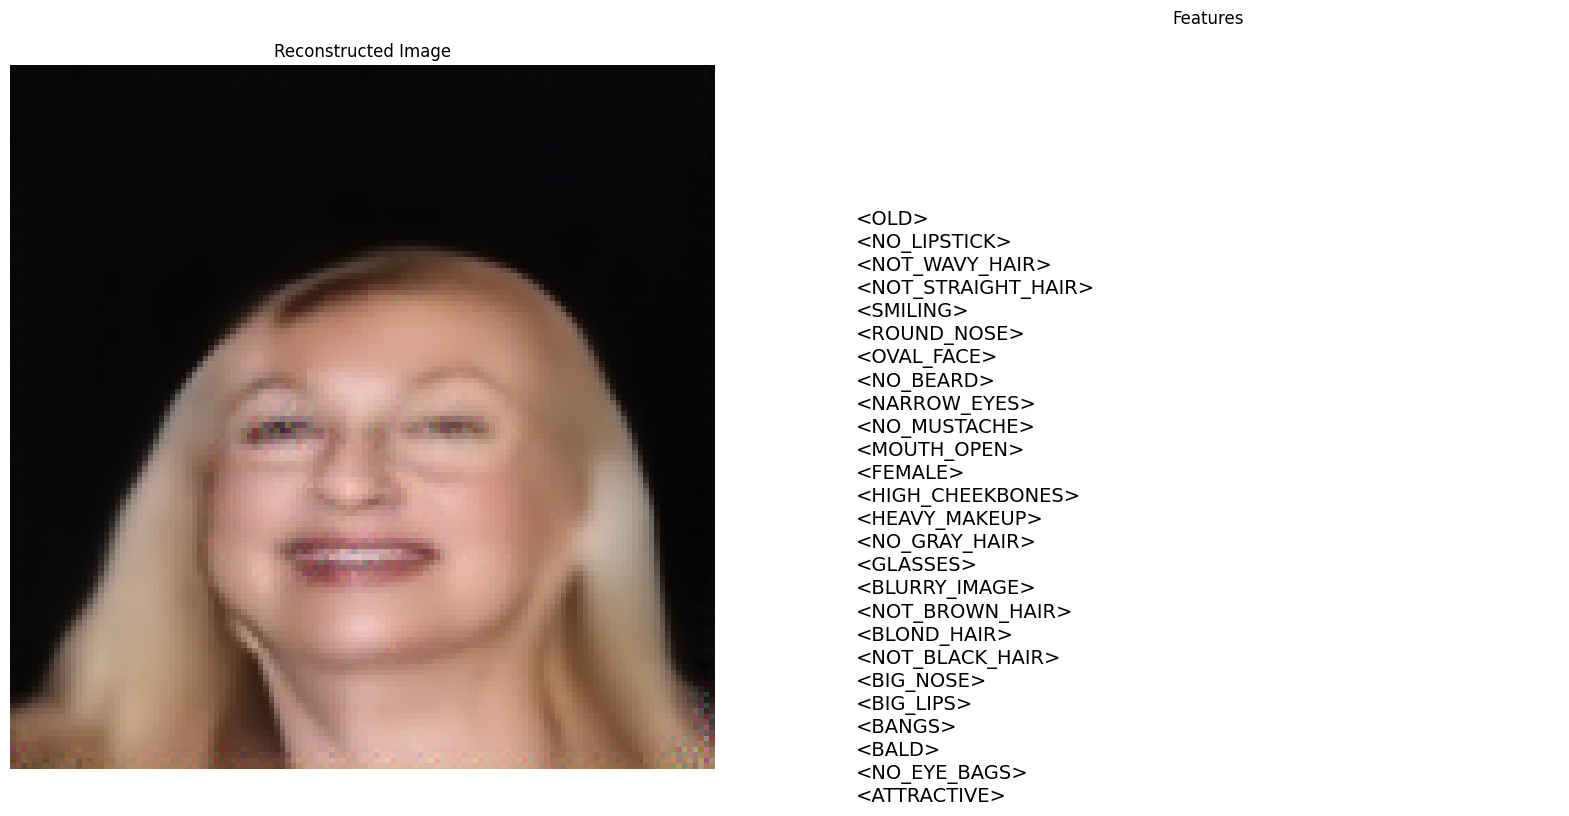

In [49]:
generate(fake_face_features())

Sequence Out:
<START_FACE> <NOT_ATTRACTIVE> <EYE_BAGS> <NOT_BALD> <NO_BANGS> <SMALL_LIPS> <BIG_NOSE> <BLACK_HAIR> <BLOND_HAIR> <BROWN_HAIR> <CLEAR_IMAGE> <GLASSES> <NO_GRAY_HAIR> <HEAVY_MAKEUP> <LOW_CHEEKBONES> <FEMALE> <MOUTH_CLOSED> <NO_MUSTACHE> <WIDE_EYES> <NO_BEARD> <NON_OVAL_FACE> <POINTY_NOSE> <NOT_SMILING> <STRAIGHT_HAIR> <WAVY_HAIR> <NO_LIPSTICK> <YOUNG> <START_GENERATION> <CODE_239> <CODE_307> <CODE_252> <CODE_442> <CODE_263> <CODE_123> <CODE_143> <CODE_489> <CODE_116> <CODE_059> <CODE_116> <CODE_365> <CODE_141> <CODE_143> <CODE_239> <CODE_307> <CODE_021> <CODE_021> <CODE_197> <CODE_263> <CODE_350> <CODE_143> <CODE_311> <CODE_372> <CODE_282> <CODE_111> <CODE_136> <CODE_136> <CODE_311> <CODE_021> <CODE_440> <CODE_060> <CODE_021> <CODE_021> <CODE_152> <CODE_252> <CODE_141> <CODE_462> <CODE_496> <CODE_178> <CODE_447> <CODE_380> <CODE_264> <CODE_368> <CODE_082> <CODE_178> <CODE_216> <CODE_417> <CODE_350> <CODE_143> <CODE_021> <CODE_252> <CODE_226> <CODE_035> <CODE_009> <CODE_414>

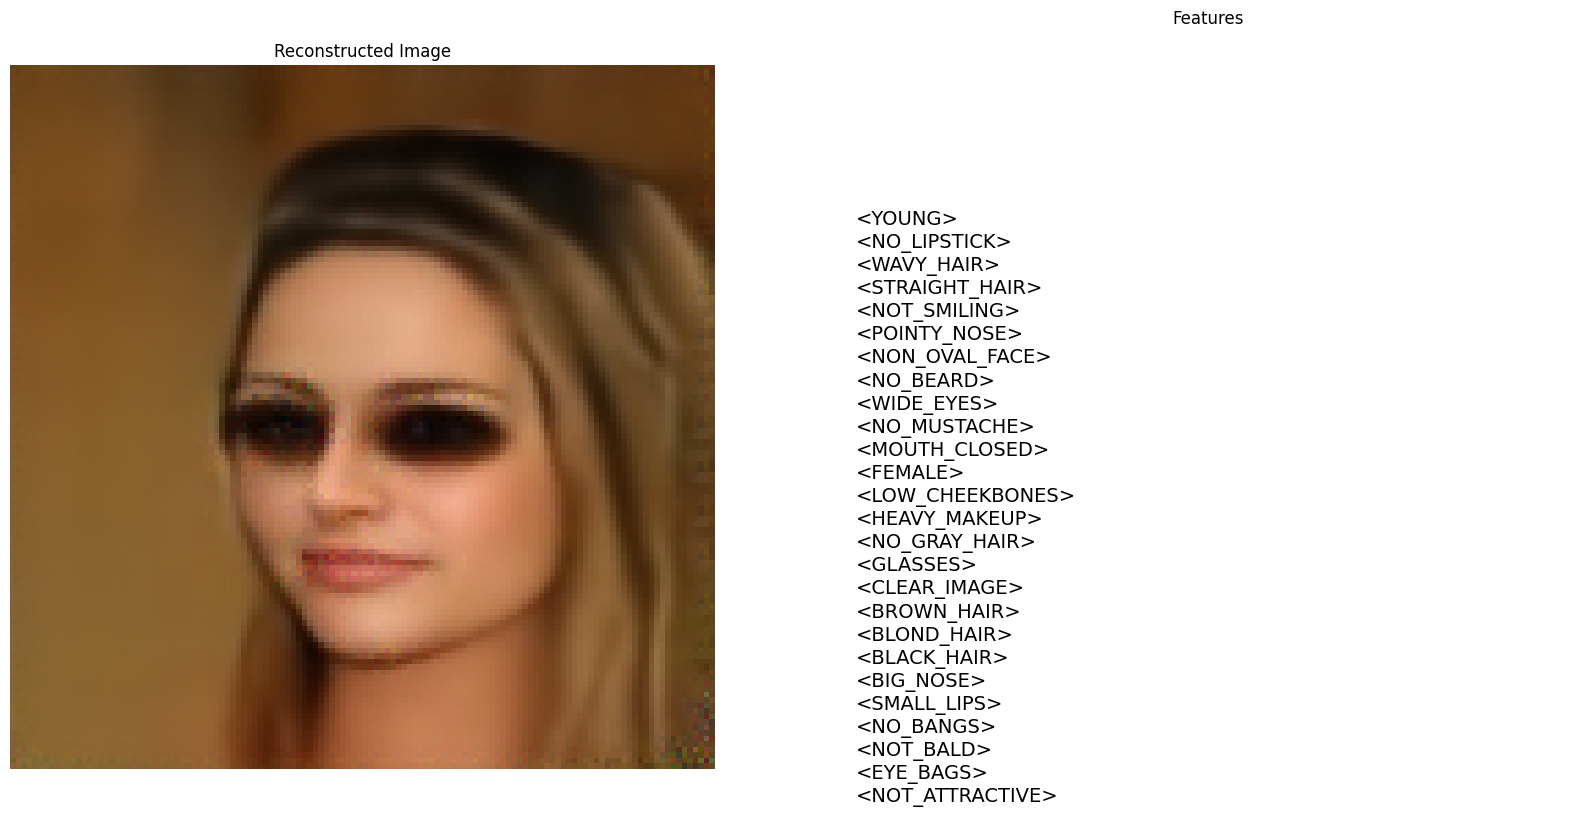

In [50]:
generate(fake_face_features())

# Train

## preparing data

In [51]:
def tokenize_function(examples):
    result = tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )

    result["labels"] = result["input_ids"].copy()

    return result

In [52]:
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

Map:   0%|          | 0/141819 [00:00<?, ? examples/s]

Map:   0%|          | 0/60780 [00:00<?, ? examples/s]

In [53]:
print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 141819
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 60780
    })
})


## Training Args

In [54]:
OUT_DIR

'gpt-faces-generator'

In [55]:
training_args = TrainingArguments(
    output_dir= OUT_DIR,

    per_device_train_batch_size=40,
    per_device_eval_batch_size=40,
    gradient_accumulation_steps=2,

    num_train_epochs=5,

    learning_rate=2e-4,

    logging_strategy="epoch",
    # logging_steps=50,

    save_strategy="epoch",
    # save_steps=1000,

    eval_strategy="epoch",
    # eval_steps=500,

    fp16=True,

    save_total_limit=1,

    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,

    push_to_hub=True,
    hub_model_id="yosef-samy019/gpt-face-celeb-generator",
)

In [56]:
trainer = Trainer(
    model=gpt_model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=DataCollatorWithPadding(tokenizer) # Automatic padding per Batch
)

In [57]:
print("Start Training...")

Start Training...


In [58]:
trainer.train()

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,3.705506,3.766952
2,3.688803,3.762657
3,3.672590,3.756875
4,3.658467,3.757971
5,3.647269,3.754685


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


TrainOutput(global_step=8865, training_loss=3.6745271410568248, metrics={'train_runtime': 16610.566, 'train_samples_per_second': 42.689, 'train_steps_per_second': 0.534, 'total_flos': 1.08563011776e+17, 'train_loss': 3.6745271410568248, 'epoch': 5.0})

# Inference

Sequence Out:
<START_FACE> <NOT_ATTRACTIVE> <NO_EYE_BAGS> <BALD> <NO_BANGS> <SMALL_LIPS> <SMALL_NOSE> <NOT_BLACK_HAIR> <NOT_BLOND_HAIR> <BROWN_HAIR> <CLEAR_IMAGE> <NO_GLASSES> <NO_GRAY_HAIR> <LIGHT_MAKEUP> <LOW_CHEEKBONES> <FEMALE> <MOUTH_CLOSED> <MUSTACHE> <WIDE_EYES> <NO_BEARD> <OVAL_FACE> <ROUND_NOSE> <NOT_SMILING> <STRAIGHT_HAIR> <WAVY_HAIR> <LIPSTICK> <OLD> <START_GENERATION> <CODE_228> <CODE_214> <CODE_214> <CODE_214> <CODE_214> <CODE_214> <CODE_214> <CODE_214> <CODE_382> <CODE_214> <CODE_214> <CODE_214> <CODE_101> <CODE_214> <CODE_214> <CODE_008> <CODE_101> <CODE_101> <CODE_101> <CODE_101> <CODE_382> <CODE_333> <CODE_101> <CODE_382> <CODE_382> <CODE_333> <CODE_333> <CODE_333> <CODE_382> <CODE_101> <CODE_382> <CODE_382> <CODE_101> <CODE_101> <CODE_101> <CODE_382> <CODE_333> <CODE_214> <CODE_328> <CODE_228> <CODE_228> <CODE_164> <CODE_328> <CODE_101> <CODE_333> <CODE_101> <CODE_101> <CODE_382> <CODE_214> <CODE_101> <CODE_101> <CODE_333> <CODE_328> <CODE_243> <CODE_456> <CODE_110> 

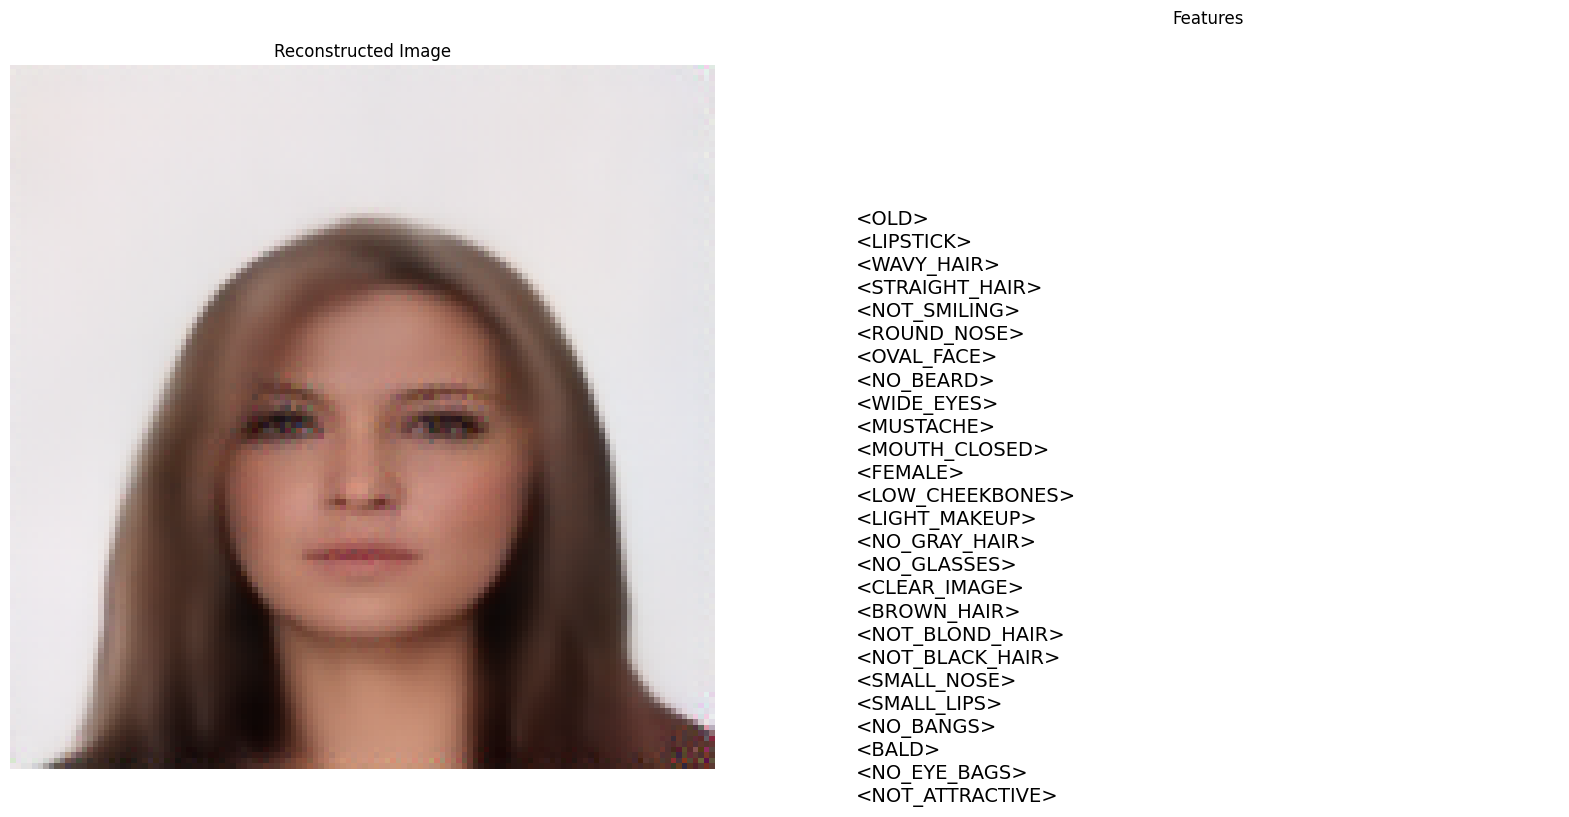

In [59]:
generate(fake_face_features())

Sequence Out:
<START_FACE> <NOT_ATTRACTIVE> <EYE_BAGS> <NOT_BALD> <NO_BANGS> <BIG_LIPS> <SMALL_NOSE> <BLACK_HAIR> <BLOND_HAIR> <BROWN_HAIR> <CLEAR_IMAGE> <GLASSES> <NO_GRAY_HAIR> <HEAVY_MAKEUP> <LOW_CHEEKBONES> <MALE> <MOUTH_OPEN> <NO_MUSTACHE> <WIDE_EYES> <BEARD> <NON_OVAL_FACE> <POINTY_NOSE> <NOT_SMILING> <NOT_STRAIGHT_HAIR> <NOT_WAVY_HAIR> <LIPSTICK> <YOUNG> <START_GENERATION> <CODE_417> <CODE_488> <CODE_192> <CODE_283> <CODE_235> <CODE_283> <CODE_283> <CODE_283> <CODE_067> <CODE_488> <CODE_192> <CODE_192> <CODE_192> <CODE_192> <CODE_283> <CODE_067> <CODE_067> <CODE_283> <CODE_283> <CODE_053> <CODE_053> <CODE_053> <CODE_232> <CODE_474> <CODE_053> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_166> <CODE_067> <CODE_067> <CODE_283> <CODE_192> <CODE_488> <CODE_330> <CODE_417> <CODE_417> <CODE_417> <CODE_417> <CODE_192> <CODE_025> <CODE_283> <CODE_283> <CODE_283> <CODE_025> <CODE_067> <CODE_192> <CODE_330> <CODE_182> <CODE_293> <CODE_108> <CODE_240> <CODE_184> <CODE_468> <

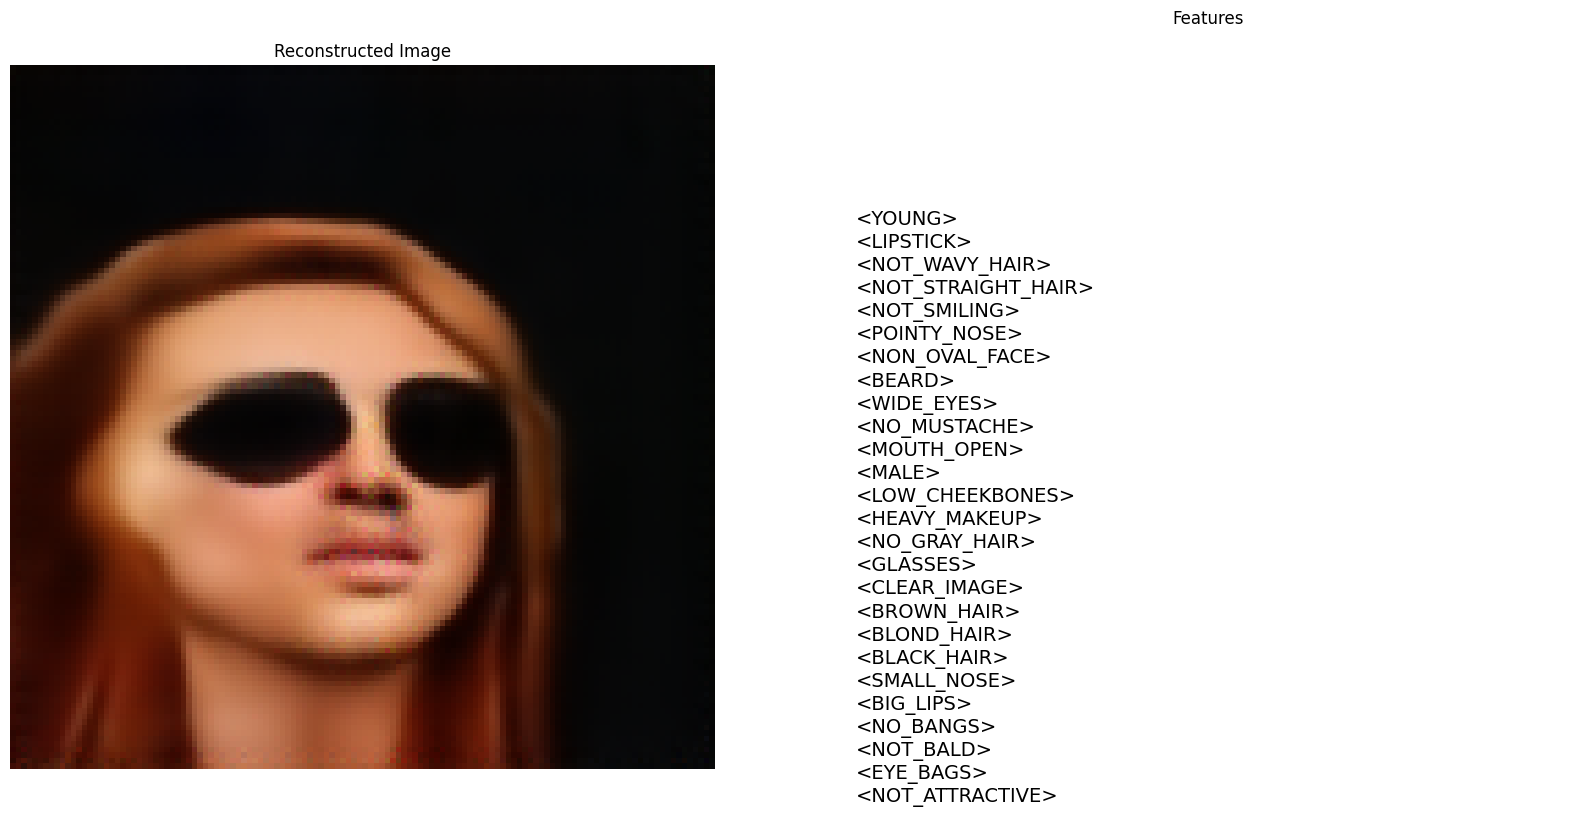

In [60]:
generate(fake_face_features())

Sequence Out:
<START_FACE> <ATTRACTIVE> <EYE_BAGS> <NOT_BALD> <BANGS> <BIG_LIPS> <SMALL_NOSE> <BLACK_HAIR> <NOT_BLOND_HAIR> <NOT_BROWN_HAIR> <CLEAR_IMAGE> <NO_GLASSES> <GRAY_HAIR> <HEAVY_MAKEUP> <HIGH_CHEEKBONES> <FEMALE> <MOUTH_OPEN> <NO_MUSTACHE> <WIDE_EYES> <BEARD> <OVAL_FACE> <POINTY_NOSE> <SMILING> <NOT_STRAIGHT_HAIR> <NOT_WAVY_HAIR> <LIPSTICK> <OLD> <START_GENERATION> <CODE_025> <CODE_190> <CODE_346> <CODE_503> <CODE_193> <CODE_503> <CODE_065> <CODE_276> <CODE_124> <CODE_207> <CODE_025> <CODE_346> <CODE_495> <CODE_232> <CODE_346> <CODE_190> <CODE_346> <CODE_346> <CODE_495> <CODE_232> <CODE_193> <CODE_180> <CODE_426> <CODE_254> <CODE_122> <CODE_132> <CODE_232> <CODE_180> <CODE_495> <CODE_346> <CODE_263> <CODE_346> <CODE_190> <CODE_346> <CODE_495> <CODE_180> <CODE_193> <CODE_162> <CODE_396> <CODE_254> <CODE_122> <CODE_105> <CODE_503> <CODE_048> <CODE_048> <CODE_180> <CODE_263> <CODE_346> <CODE_346> <CODE_263> <CODE_263> <CODE_232> <CODE_396> <CODE_222> <CODE_377> <CODE_457> <CODE_3

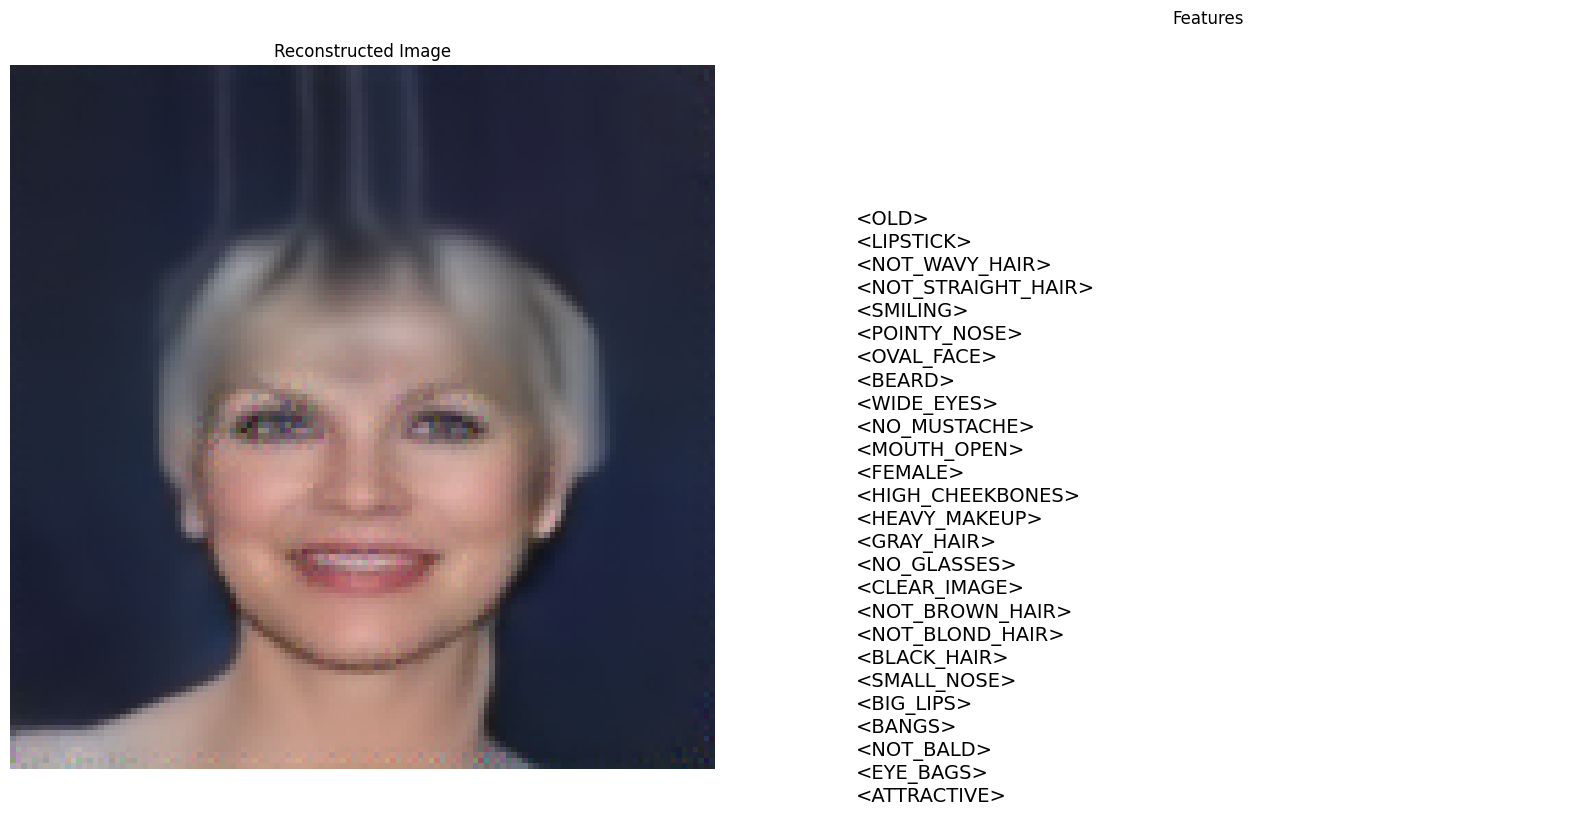

In [61]:
generate(fake_face_features())

Sequence Out:
<START_FACE> <ATTRACTIVE> <EYE_BAGS> <BALD> <NO_BANGS> <BIG_LIPS> <SMALL_NOSE> <NOT_BLACK_HAIR> <BLOND_HAIR> <BROWN_HAIR> <BLURRY_IMAGE> <GLASSES> <NO_GRAY_HAIR> <LIGHT_MAKEUP> <HIGH_CHEEKBONES> <FEMALE> <MOUTH_CLOSED> <NO_MUSTACHE> <WIDE_EYES> <BEARD> <OVAL_FACE> <ROUND_NOSE> <SMILING> <STRAIGHT_HAIR> <WAVY_HAIR> <LIPSTICK> <OLD> <START_GENERATION> <CODE_021> <CODE_021> <CODE_141> <CODE_059> <CODE_060> <CODE_391> <CODE_350> <CODE_440> <CODE_224> <CODE_073> <CODE_350> <CODE_350> <CODE_141> <CODE_141> <CODE_350> <CODE_350> <CODE_059> <CODE_059> <CODE_224> <CODE_110> <CODE_259> <CODE_184> <CODE_336> <CODE_359> <CODE_487> <CODE_347> <CODE_224> <CODE_226> <CODE_021> <CODE_252> <CODE_059> <CODE_350> <CODE_021> <CODE_226> <CODE_263> <CODE_500> <CODE_007> <CODE_158> <CODE_422> <CODE_138> <CODE_324> <CODE_316> <CODE_270> <CODE_263> <CODE_224> <CODE_226> <CODE_059> <CODE_021> <CODE_059> <CODE_060> <CODE_507> <CODE_334> <CODE_278> <CODE_173> <CODE_113> <CODE_162> <CODE_358> <CODE_3

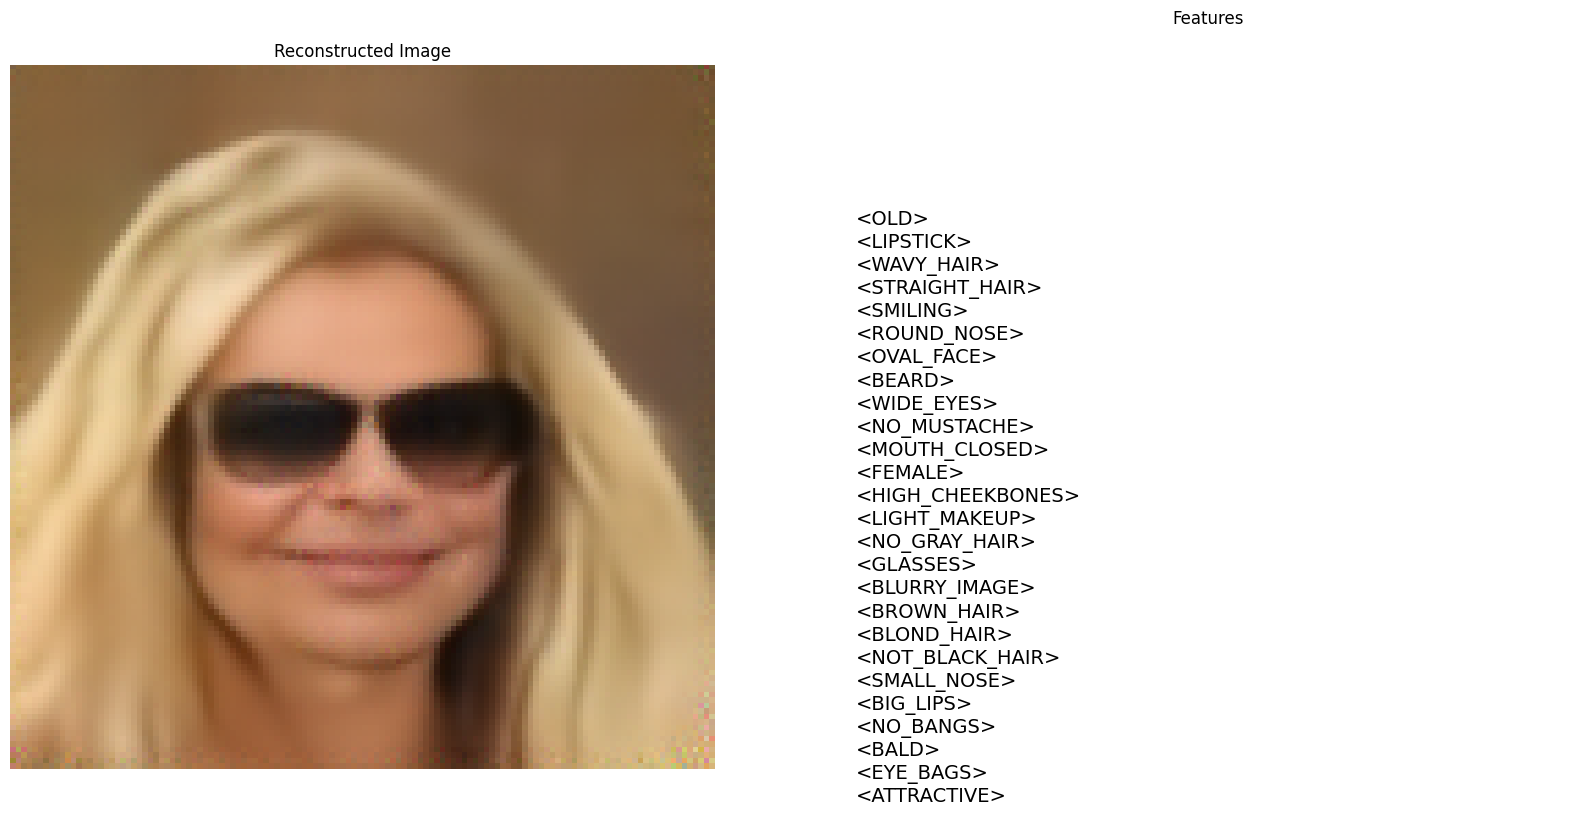

In [62]:
generate(fake_face_features())

Sequence Out:
<START_FACE> <NOT_ATTRACTIVE> <EYE_BAGS> <BALD> <NO_BANGS> <BIG_LIPS> <BIG_NOSE> <NOT_BLACK_HAIR> <BLOND_HAIR> <NOT_BROWN_HAIR> <BLURRY_IMAGE> <NO_GLASSES> <NO_GRAY_HAIR> <HEAVY_MAKEUP> <LOW_CHEEKBONES> <FEMALE> <MOUTH_OPEN> <NO_MUSTACHE> <WIDE_EYES> <NO_BEARD> <OVAL_FACE> <ROUND_NOSE> <NOT_SMILING> <STRAIGHT_HAIR> <WAVY_HAIR> <NO_LIPSTICK> <OLD> <START_GENERATION> <CODE_067> <CODE_192> <CODE_192> <CODE_192> <CODE_192> <CODE_192> <CODE_192> <CODE_192> <CODE_067> <CODE_067> <CODE_067> <CODE_067> <CODE_067> <CODE_067> <CODE_067> <CODE_067> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_067> <CODE_192> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_025> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_283> <CODE_067> <CODE_192> <CODE_283> <CODE_283> <CODE_192> <CODE_283> <CODE_283> <CODE_067> <CODE_417> <C

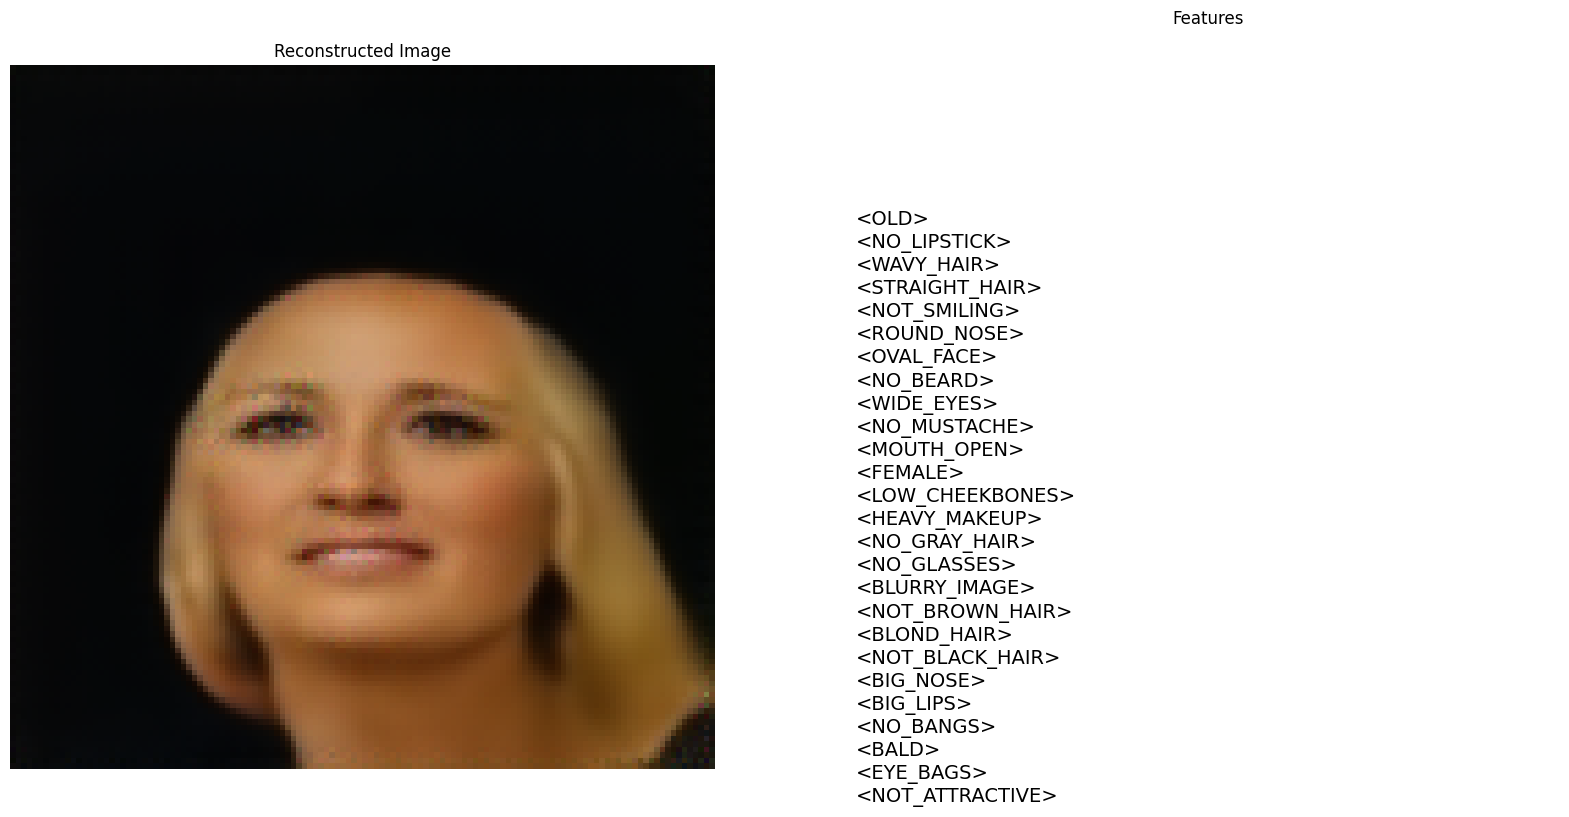

In [63]:
generate(fake_face_features())

Sequence Out:
<START_FACE> <NOT_ATTRACTIVE> <NO_EYE_BAGS> <NOT_BALD> <BANGS> <SMALL_LIPS> <SMALL_NOSE> <NOT_BLACK_HAIR> <BLOND_HAIR> <NOT_BROWN_HAIR> <BLURRY_IMAGE> <GLASSES> <NO_GRAY_HAIR> <LIGHT_MAKEUP> <HIGH_CHEEKBONES> <MALE> <MOUTH_OPEN> <MUSTACHE> <NARROW_EYES> <BEARD> <NON_OVAL_FACE> <ROUND_NOSE> <NOT_SMILING> <STRAIGHT_HAIR> <NOT_WAVY_HAIR> <NO_LIPSTICK> <OLD> <START_GENERATION> <CODE_214> <CODE_101> <CODE_382> <CODE_382> <CODE_333> <CODE_382> <CODE_214> <CODE_144> <CODE_328> <CODE_251> <CODE_008> <CODE_333> <CODE_333> <CODE_382> <CODE_382> <CODE_382> <CODE_101> <CODE_333> <CODE_333> <CODE_333> <CODE_008> <CODE_243> <CODE_382> <CODE_461> <CODE_119> <CODE_281> <CODE_243> <CODE_297> <CODE_382> <CODE_333> <CODE_333> <CODE_382> <CODE_101> <CODE_333> <CODE_333> <CODE_251> <CODE_325> <CODE_291> <CODE_192> <CODE_413> <CODE_140> <CODE_347> <CODE_487> <CODE_355> <CODE_164> <CODE_101> <CODE_333> <CODE_382> <CODE_101> <CODE_333> <CODE_214> <CODE_151> <CODE_392> <CODE_134> <CODE_462> <CODE

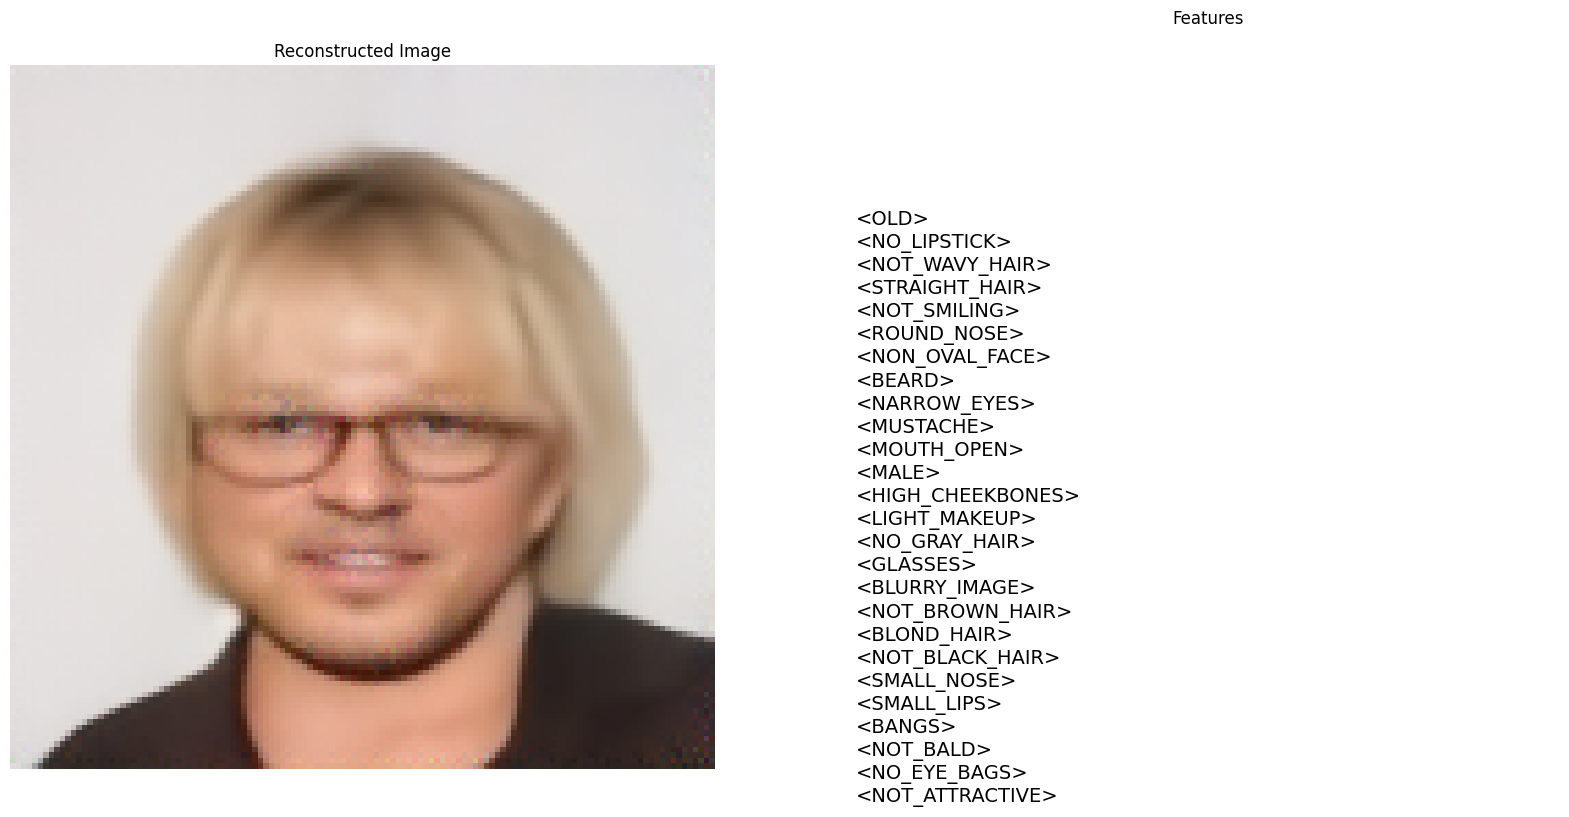

In [64]:
generate(fake_face_features())

Sequence Out:
<START_FACE> <NOT_ATTRACTIVE> <NO_EYE_BAGS> <NOT_BALD> <NO_BANGS> <SMALL_LIPS> <SMALL_NOSE> <BLACK_HAIR> <NOT_BLOND_HAIR> <NOT_BROWN_HAIR> <BLURRY_IMAGE> <GLASSES> <NO_GRAY_HAIR> <LIGHT_MAKEUP> <HIGH_CHEEKBONES> <FEMALE> <MOUTH_OPEN> <MUSTACHE> <WIDE_EYES> <BEARD> <NON_OVAL_FACE> <POINTY_NOSE> <SMILING> <STRAIGHT_HAIR> <WAVY_HAIR> <LIPSTICK> <OLD> <START_GENERATION> <CODE_248> <CODE_092> <CODE_008> <CODE_333> <CODE_382> <CODE_333> <CODE_214> <CODE_382> <CODE_382> <CODE_436> <CODE_436> <CODE_436> <CODE_436> <CODE_382> <CODE_382> <CODE_382> <CODE_420> <CODE_228> <CODE_205> <CODE_328> <CODE_251> <CODE_328> <CODE_081> <CODE_499> <CODE_251> <CODE_328> <CODE_436> <CODE_248> <CODE_436> <CODE_436> <CODE_248> <CODE_436> <CODE_036> <CODE_462> <CODE_149> <CODE_219> <CODE_437> <CODE_413> <CODE_417> <CODE_203> <CODE_288> <CODE_458> <CODE_297> <CODE_008> <CODE_248> <CODE_436> <CODE_436> <CODE_382> <CODE_294> <CODE_156> <CODE_447> <CODE_203> <CODE_426> <CODE_096> <CODE_371> <CODE_097> <

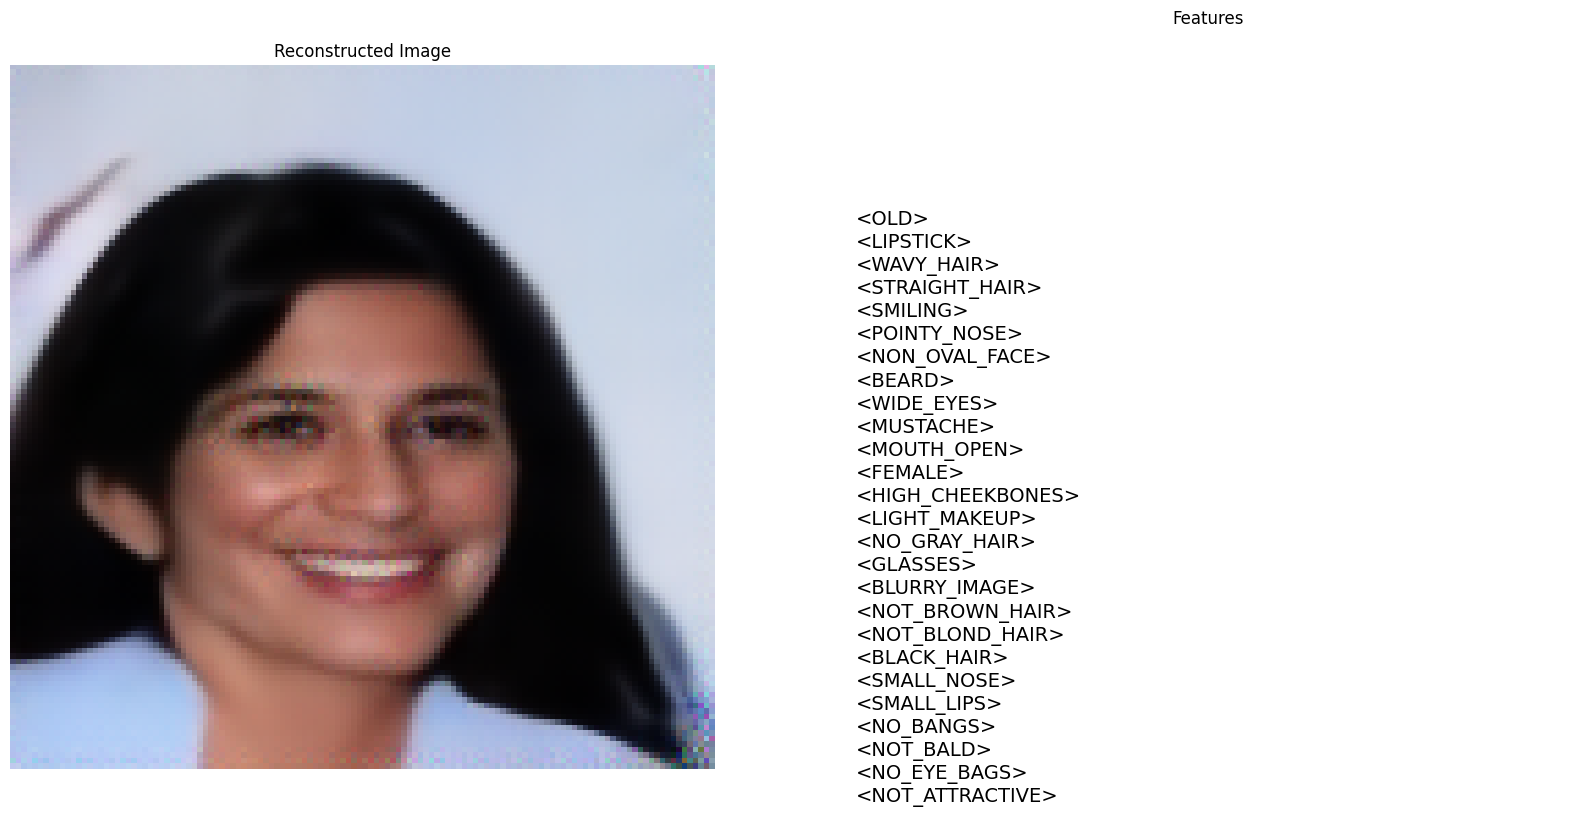

In [65]:
generate(fake_face_features())

Sequence Out:
<START_FACE> <NOT_ATTRACTIVE> <NO_EYE_BAGS> <BALD> <BANGS> <SMALL_LIPS> <SMALL_NOSE> <NOT_BLACK_HAIR> <NOT_BLOND_HAIR> <BROWN_HAIR> <CLEAR_IMAGE> <GLASSES> <NO_GRAY_HAIR> <HEAVY_MAKEUP> <HIGH_CHEEKBONES> <FEMALE> <MOUTH_CLOSED> <MUSTACHE> <WIDE_EYES> <BEARD> <NON_OVAL_FACE> <ROUND_NOSE> <NOT_SMILING> <NOT_STRAIGHT_HAIR> <WAVY_HAIR> <LIPSTICK> <YOUNG> <START_GENERATION> <CODE_251> <CODE_008> <CODE_214> <CODE_214> <CODE_382> <CODE_382> <CODE_382> <CODE_382> <CODE_382> <CODE_008> <CODE_008> <CODE_382> <CODE_008> <CODE_008> <CODE_008> <CODE_251> <CODE_008> <CODE_382> <CODE_382> <CODE_382> <CODE_436> <CODE_436> <CODE_008> <CODE_008> <CODE_008> <CODE_382> <CODE_436> <CODE_436> <CODE_382> <CODE_382> <CODE_382> <CODE_008> <CODE_214> <CODE_382> <CODE_382> <CODE_382> <CODE_008> <CODE_328> <CODE_214> <CODE_363> <CODE_101> <CODE_100> <CODE_100> <CODE_382> <CODE_436> <CODE_382> <CODE_382> <CODE_008> <CODE_214> <CODE_382> <CODE_436> <CODE_251> <CODE_285> <CODE_440> <CODE_343> <CODE_326

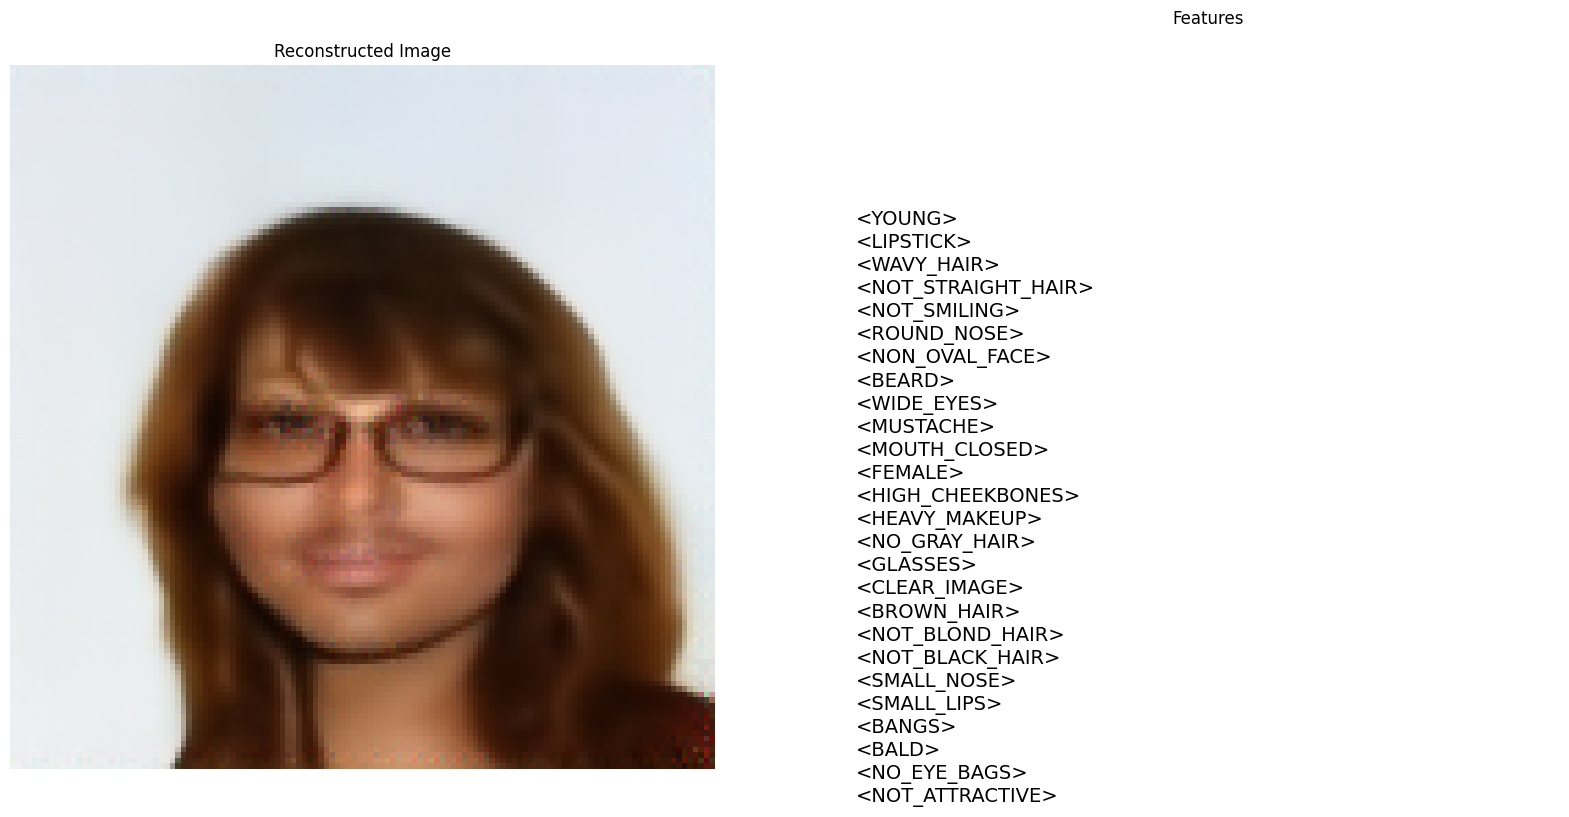

In [66]:
generate(fake_face_features())

Sequence Out:
<START_FACE> <NOT_ATTRACTIVE> <EYE_BAGS> <NOT_BALD> <NO_BANGS> <BIG_LIPS> <SMALL_NOSE> <BLACK_HAIR> <BLOND_HAIR> <BROWN_HAIR> <BLURRY_IMAGE> <GLASSES> <GRAY_HAIR> <LIGHT_MAKEUP> <LOW_CHEEKBONES> <MALE> <MOUTH_CLOSED> <NO_MUSTACHE> <WIDE_EYES> <NO_BEARD> <NON_OVAL_FACE> <ROUND_NOSE> <SMILING> <NOT_STRAIGHT_HAIR> <NOT_WAVY_HAIR> <NO_LIPSTICK> <OLD> <START_GENERATION> <CODE_263> <CODE_252> <CODE_263> <CODE_263> <CODE_263> <CODE_263> <CODE_048> <CODE_263> <CODE_365> <CODE_350> <CODE_365> <CODE_263> <CODE_252> <CODE_263> <CODE_263> <CODE_263> <CODE_263> <CODE_263> <CODE_365> <CODE_263> <CODE_048> <CODE_391> <CODE_190> <CODE_404> <CODE_346> <CODE_263> <CODE_252> <CODE_365> <CODE_252> <CODE_263> <CODE_365> <CODE_263> <CODE_252> <CODE_252> <CODE_252> <CODE_048> <CODE_347> <CODE_396> <CODE_240> <CODE_348> <CODE_475> <CODE_124> <CODE_190> <CODE_226> <CODE_252> <CODE_252> <CODE_226> <CODE_252> <CODE_252> <CODE_252> <CODE_048> <CODE_190> <CODE_216> <CODE_138> <CODE_291> <CODE_119> <C

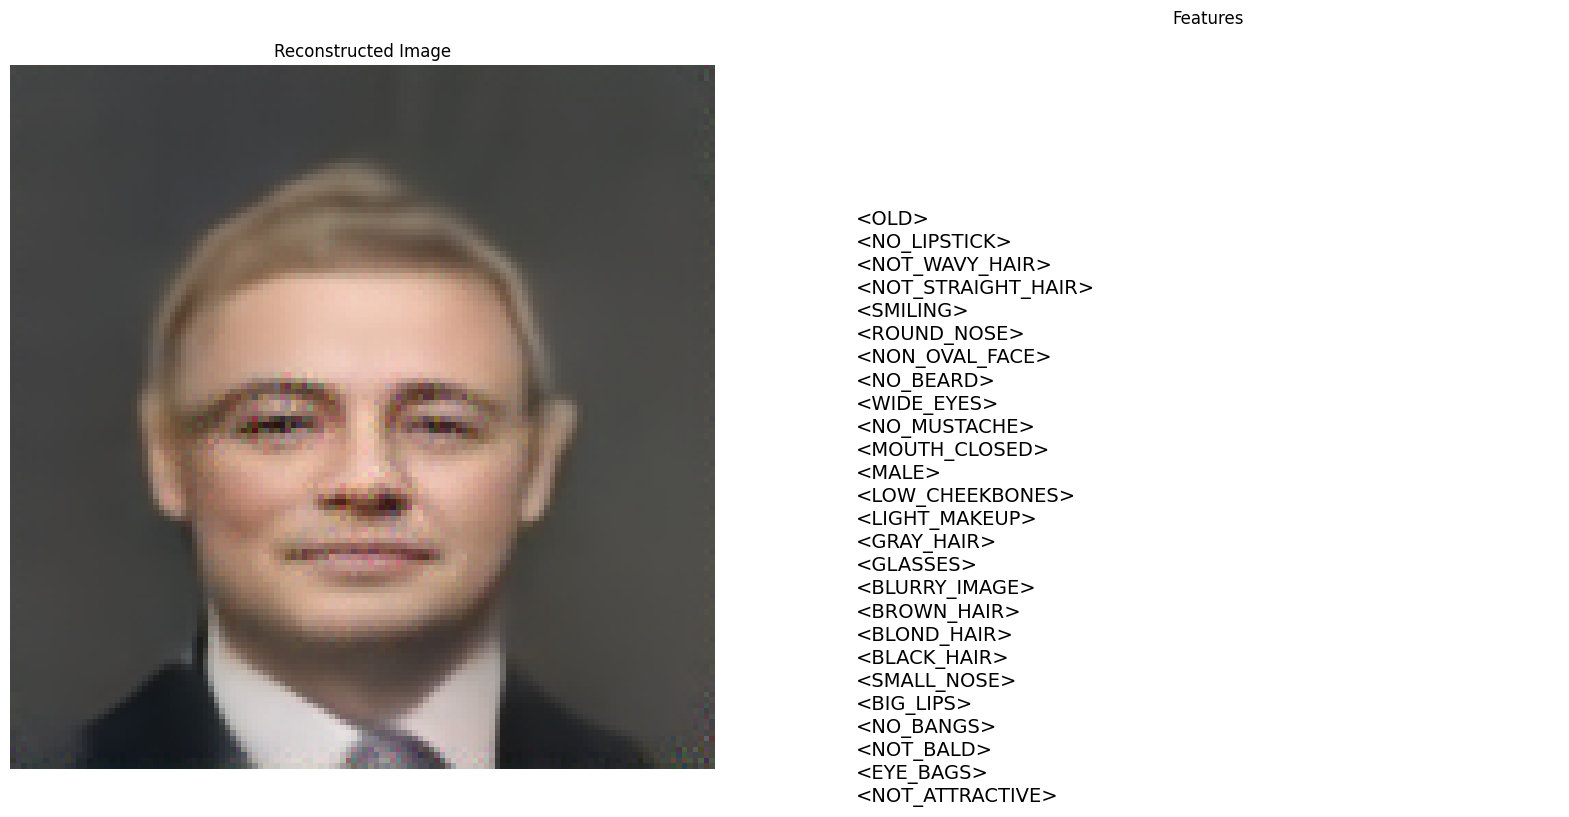

In [67]:
generate(fake_face_features())

Sequence Out:
<START_FACE> <NOT_ATTRACTIVE> <NO_EYE_BAGS> <NOT_BALD> <BANGS> <SMALL_LIPS> <SMALL_NOSE> <NOT_BLACK_HAIR> <NOT_BLOND_HAIR> <BROWN_HAIR> <BLURRY_IMAGE> <GLASSES> <NO_GRAY_HAIR> <HEAVY_MAKEUP> <LOW_CHEEKBONES> <MALE> <MOUTH_OPEN> <NO_MUSTACHE> <NARROW_EYES> <NO_BEARD> <OVAL_FACE> <ROUND_NOSE> <NOT_SMILING> <STRAIGHT_HAIR> <NOT_WAVY_HAIR> <NO_LIPSTICK> <OLD> <START_GENERATION> <CODE_417> <CODE_488> <CODE_488> <CODE_488> <CODE_488> <CODE_488> <CODE_488> <CODE_488> <CODE_488> <CODE_488> <CODE_488> <CODE_488> <CODE_488> <CODE_488> <CODE_488> <CODE_417> <CODE_488> <CODE_192> <CODE_192> <CODE_192> <CODE_192> <CODE_488> <CODE_288> <CODE_488> <CODE_488> <CODE_488> <CODE_192> <CODE_192> <CODE_192> <CODE_192> <CODE_192> <CODE_488> <CODE_488> <CODE_192> <CODE_088> <CODE_488> <CODE_417> <CODE_027> <CODE_496> <CODE_052> <CODE_208> <CODE_177> <CODE_330> <CODE_488> <CODE_088> <CODE_192> <CODE_192> <CODE_488> <CODE_488> <CODE_079> <CODE_488> <CODE_488> <CODE_260> <CODE_341> <CODE_480> <COD

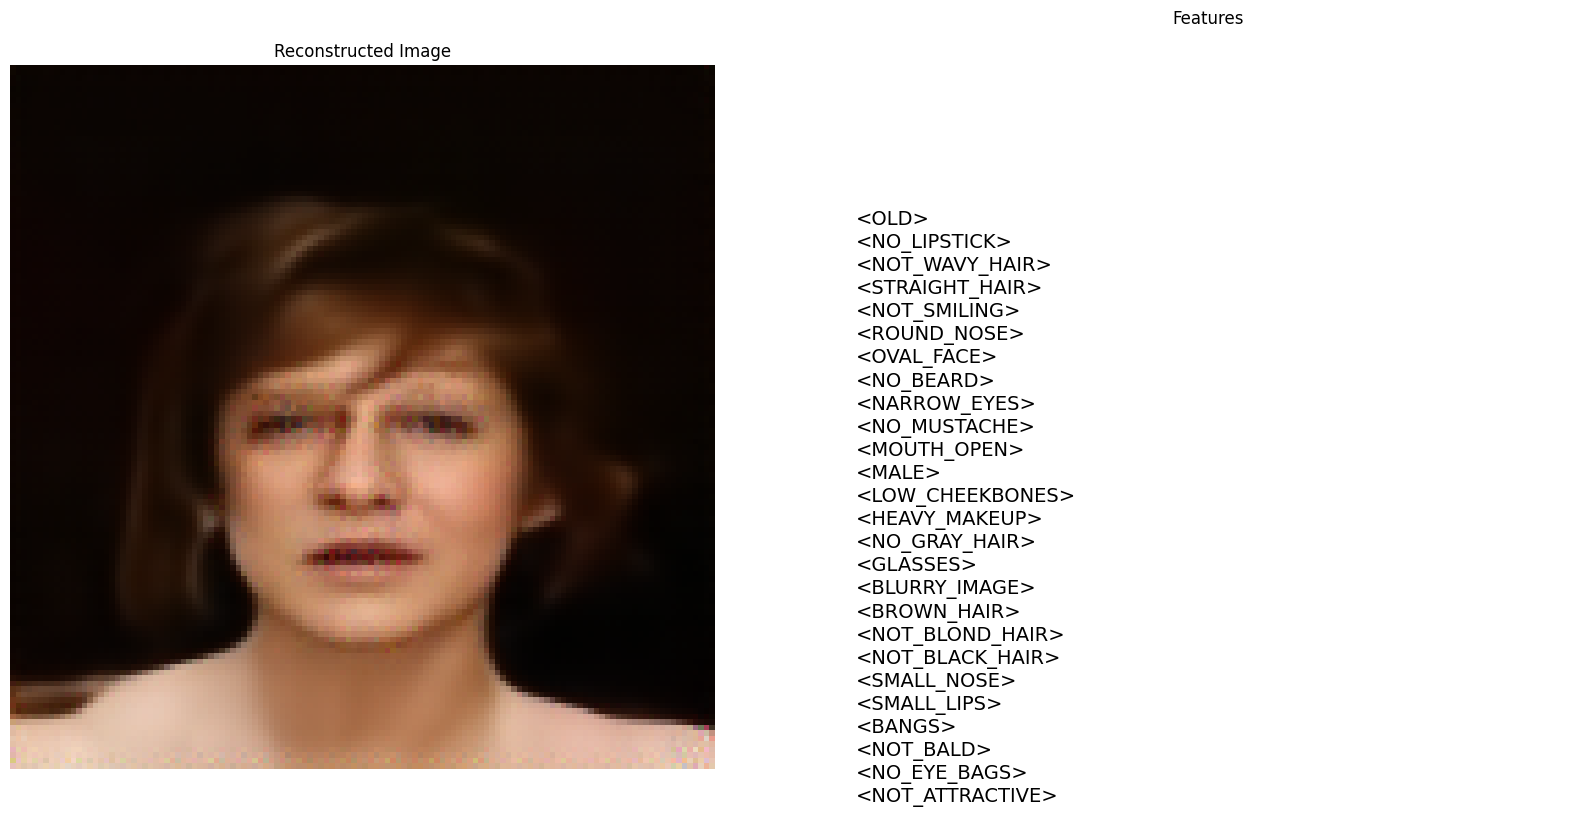

In [68]:
generate(fake_face_features())

Sequence Out:
<START_FACE> <ATTRACTIVE> <NO_EYE_BAGS> <BALD> <NO_BANGS> <SMALL_LIPS> <BIG_NOSE> <BLACK_HAIR> <NOT_BLOND_HAIR> <BROWN_HAIR> <BLURRY_IMAGE> <NO_GLASSES> <GRAY_HAIR> <LIGHT_MAKEUP> <LOW_CHEEKBONES> <MALE> <MOUTH_CLOSED> <NO_MUSTACHE> <WIDE_EYES> <NO_BEARD> <OVAL_FACE> <ROUND_NOSE> <SMILING> <NOT_STRAIGHT_HAIR> <WAVY_HAIR> <LIPSTICK> <YOUNG> <START_GENERATION> <CODE_059> <CODE_021> <CODE_059> <CODE_059> <CODE_059> <CODE_021> <CODE_021> <CODE_059> <CODE_059> <CODE_021> <CODE_059> <CODE_059> <CODE_059> <CODE_059> <CODE_059> <CODE_059> <CODE_021> <CODE_224> <CODE_059> <CODE_059> <CODE_059> <CODE_461> <CODE_344> <CODE_152> <CODE_152> <CODE_461> <CODE_073> <CODE_059> <CODE_059> <CODE_059> <CODE_059> <CODE_059> <CODE_059> <CODE_059> <CODE_059> <CODE_383> <CODE_030> <CODE_040> <CODE_066> <CODE_193> <CODE_426> <CODE_110> <CODE_284> <CODE_345> <CODE_059> <CODE_059> <CODE_059> <CODE_059> <CODE_059> <CODE_021> <CODE_383> <CODE_284> <CODE_326> <CODE_110> <CODE_192> <CODE_110> <CODE_380

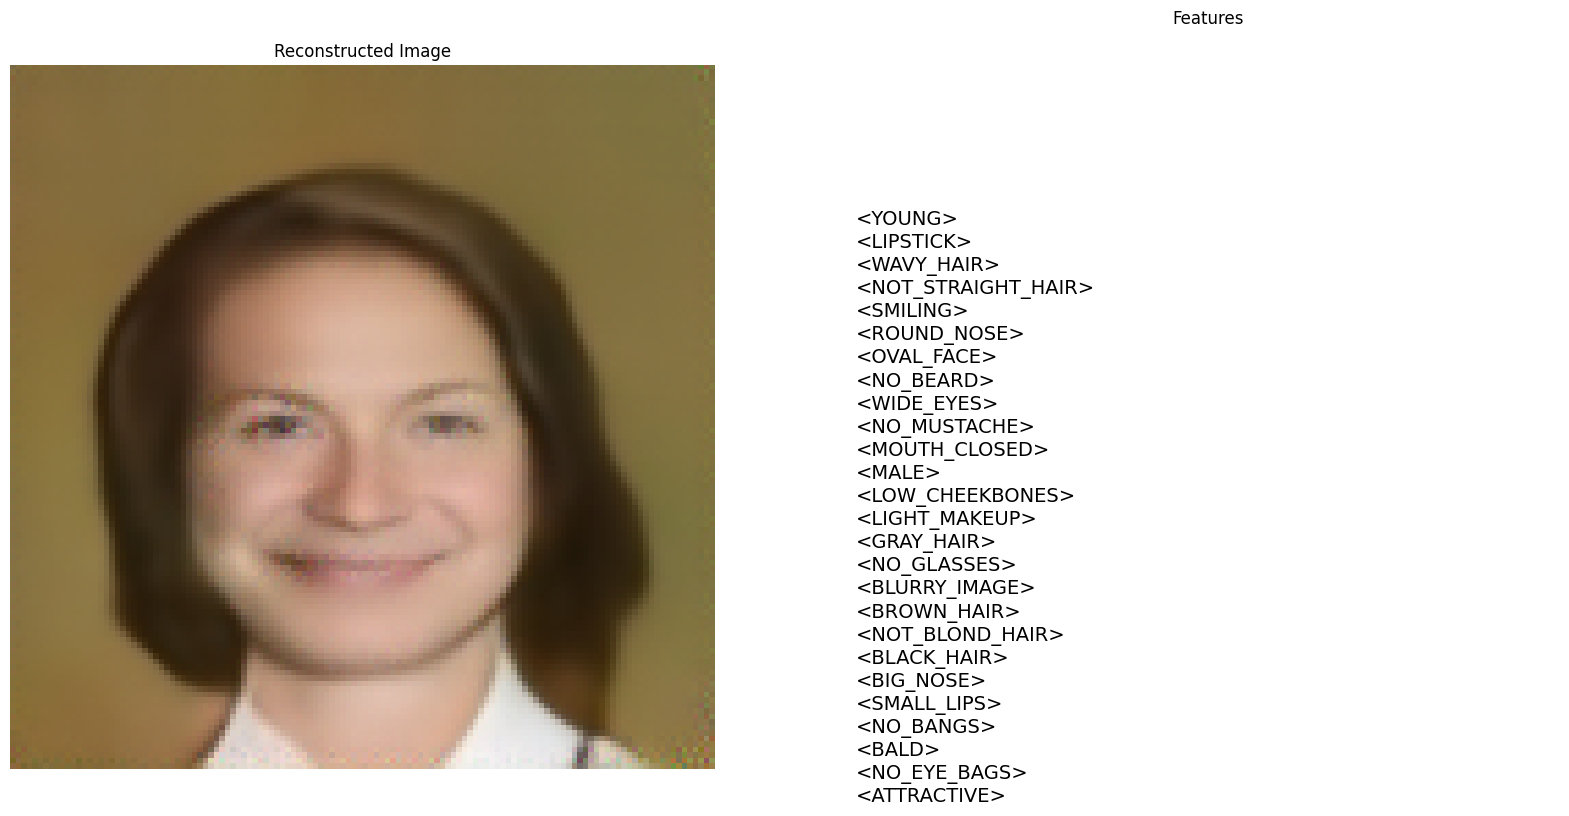

In [69]:
generate(fake_face_features())

Sequence Out:
<START_FACE> <NOT_ATTRACTIVE> <NO_EYE_BAGS> <BALD> <BANGS> <SMALL_LIPS> <SMALL_NOSE> <BLACK_HAIR> <NOT_BLOND_HAIR> <BROWN_HAIR> <CLEAR_IMAGE> <GLASSES> <GRAY_HAIR> <LIGHT_MAKEUP> <LOW_CHEEKBONES> <FEMALE> <MOUTH_CLOSED> <NO_MUSTACHE> <NARROW_EYES> <BEARD> <OVAL_FACE> <ROUND_NOSE> <NOT_SMILING> <STRAIGHT_HAIR> <WAVY_HAIR> <NO_LIPSTICK> <YOUNG> <START_GENERATION> <CODE_283> <CODE_503> <CODE_232> <CODE_503> <CODE_232> <CODE_190> <CODE_503> <CODE_283> <CODE_503> <CODE_232> <CODE_503> <CODE_232> <CODE_503> <CODE_503> <CODE_503> <CODE_283> <CODE_503> <CODE_503> <CODE_503> <CODE_232> <CODE_025> <CODE_232> <CODE_190> <CODE_503> <CODE_503> <CODE_232> <CODE_232> <CODE_232> <CODE_503> <CODE_232> <CODE_232> <CODE_283> <CODE_503> <CODE_190> <CODE_190> <CODE_503> <CODE_232> <CODE_503> <CODE_192> <CODE_283> <CODE_503> <CODE_503> <CODE_503> <CODE_503> <CODE_503> <CODE_503> <CODE_232> <CODE_283> <CODE_503> <CODE_190> <CODE_232> <CODE_346> <CODE_288> <CODE_368> <CODE_017> <CODE_396> <CODE_

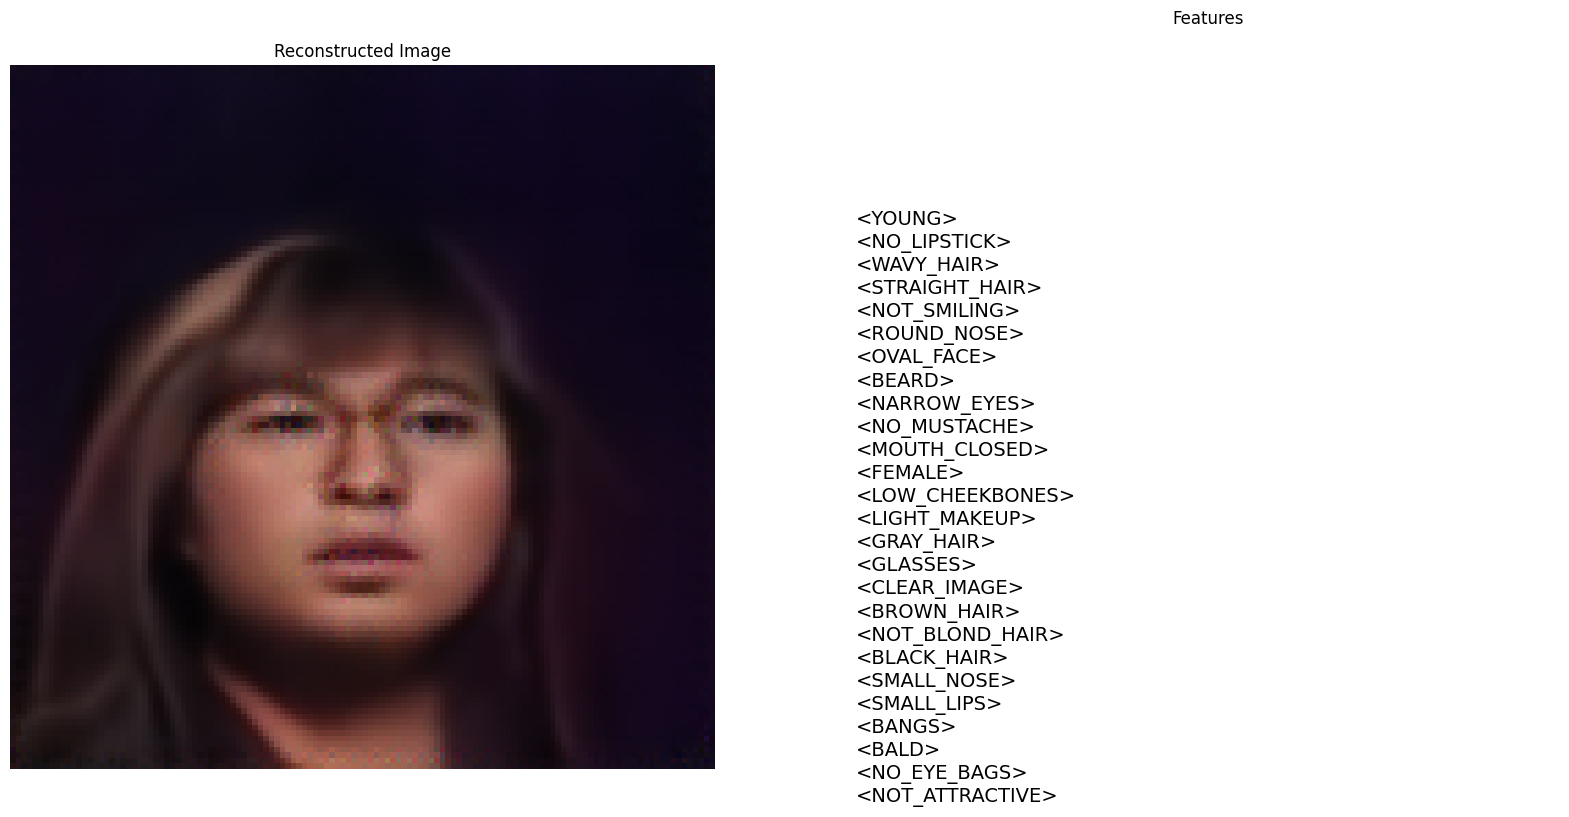

In [70]:
generate(fake_face_features())

Sequence Out:
<START_FACE> <NOT_ATTRACTIVE> <NO_EYE_BAGS> <NOT_BALD> <BANGS> <BIG_LIPS> <SMALL_NOSE> <NOT_BLACK_HAIR> <NOT_BLOND_HAIR> <NOT_BROWN_HAIR> <BLURRY_IMAGE> <NO_GLASSES> <NO_GRAY_HAIR> <HEAVY_MAKEUP> <HIGH_CHEEKBONES> <FEMALE> <MOUTH_OPEN> <NO_MUSTACHE> <WIDE_EYES> <NO_BEARD> <NON_OVAL_FACE> <POINTY_NOSE> <NOT_SMILING> <NOT_STRAIGHT_HAIR> <WAVY_HAIR> <LIPSTICK> <YOUNG> <START_GENERATION> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_188> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_195> <CODE_435> <CODE_435> <CODE_195> <CODE_195> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_072> <CODE_356> <CODE_231> <CODE_232> <CODE

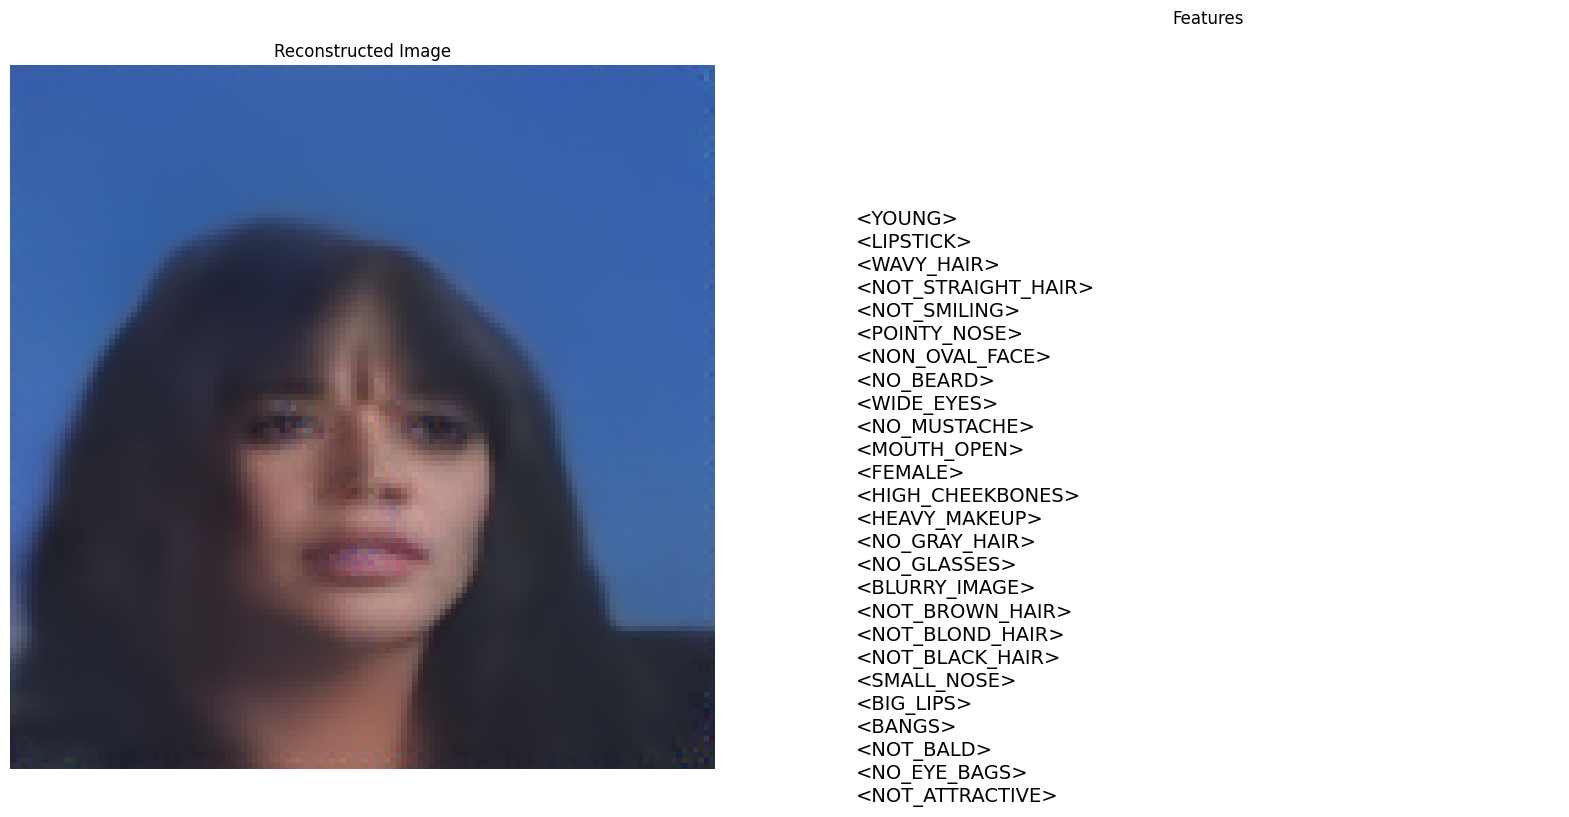

In [71]:
generate(fake_face_features())

Sequence Out:
<START_FACE> <NOT_ATTRACTIVE> <NO_EYE_BAGS> <NOT_BALD> <NO_BANGS> <BIG_LIPS> <BIG_NOSE> <BLACK_HAIR> <NOT_BLOND_HAIR> <BROWN_HAIR> <BLURRY_IMAGE> <GLASSES> <GRAY_HAIR> <LIGHT_MAKEUP> <LOW_CHEEKBONES> <MALE> <MOUTH_CLOSED> <MUSTACHE> <WIDE_EYES> <BEARD> <OVAL_FACE> <POINTY_NOSE> <SMILING> <STRAIGHT_HAIR> <NOT_WAVY_HAIR> <LIPSTICK> <OLD> <START_GENERATION> <CODE_263> <CODE_252> <CODE_263> <CODE_048> <CODE_263> <CODE_252> <CODE_263> <CODE_263> <CODE_048> <CODE_263> <CODE_263> <CODE_263> <CODE_263> <CODE_263> <CODE_048> <CODE_263> <CODE_263> <CODE_252> <CODE_252> <CODE_048> <CODE_252> <CODE_252> <CODE_048> <CODE_048> <CODE_252> <CODE_226> <CODE_048> <CODE_263> <CODE_252> <CODE_252> <CODE_252> <CODE_263> <CODE_252> <CODE_252> <CODE_252> <CODE_252> <CODE_048> <CODE_029> <CODE_451> <CODE_451> <CODE_029> <CODE_347> <CODE_451> <CODE_063> <CODE_048> <CODE_252> <CODE_252> <CODE_252> <CODE_252> <CODE_252> <CODE_252> <CODE_048> <CODE_383> <CODE_372> <CODE_247> <CODE_204> <CODE_371> <C

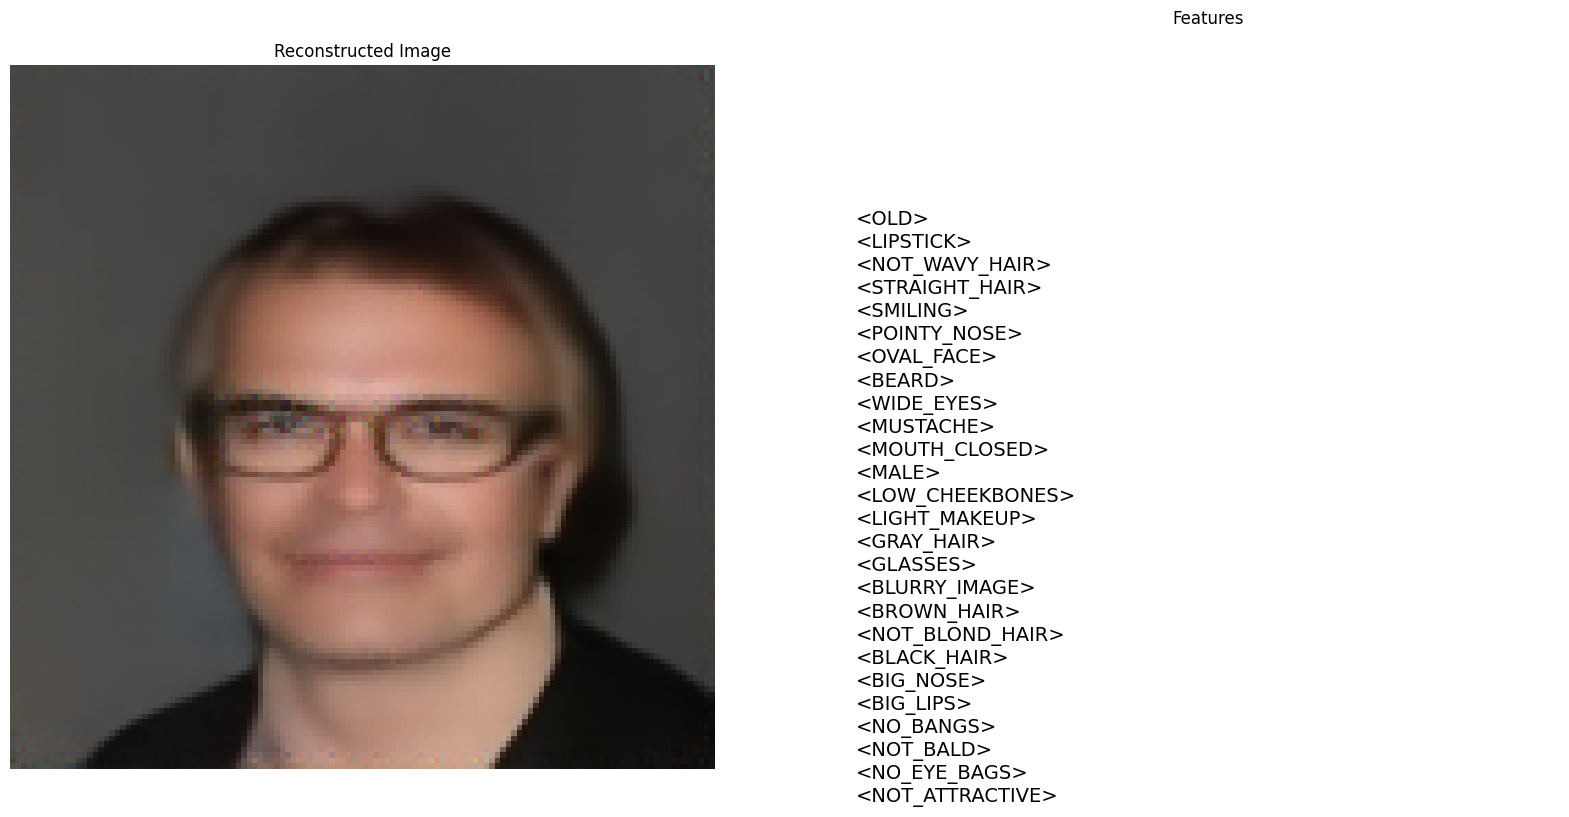

In [72]:
generate(fake_face_features())

Sequence Out:
<START_FACE> <ATTRACTIVE> <NO_EYE_BAGS> <BALD> <NO_BANGS> <SMALL_LIPS> <BIG_NOSE> <BLACK_HAIR> <NOT_BLOND_HAIR> <BROWN_HAIR> <BLURRY_IMAGE> <NO_GLASSES> <GRAY_HAIR> <HEAVY_MAKEUP> <HIGH_CHEEKBONES> <MALE> <MOUTH_OPEN> <MUSTACHE> <WIDE_EYES> <BEARD> <OVAL_FACE> <POINTY_NOSE> <NOT_SMILING> <STRAIGHT_HAIR> <WAVY_HAIR> <NO_LIPSTICK> <YOUNG> <START_GENERATION> <CODE_263> <CODE_263> <CODE_263> <CODE_263> <CODE_048> <CODE_263> <CODE_263> <CODE_263> <CODE_263> <CODE_263> <CODE_263> <CODE_048> <CODE_263> <CODE_263> <CODE_263> <CODE_263> <CODE_252> <CODE_263> <CODE_048> <CODE_048> <CODE_252> <CODE_263> <CODE_048> <CODE_048> <CODE_048> <CODE_263> <CODE_263> <CODE_048> <CODE_263> <CODE_263> <CODE_252> <CODE_263> <CODE_252> <CODE_226> <CODE_141> <CODE_347> <CODE_487> <CODE_346> <CODE_350> <CODE_237> <CODE_237> <CODE_252> <CODE_048> <CODE_048> <CODE_252> <CODE_252> <CODE_252> <CODE_263> <CODE_048> <CODE_350> <CODE_396> <CODE_299> <CODE_508> <CODE_284> <CODE_356> <CODE_291> <CODE_116> <

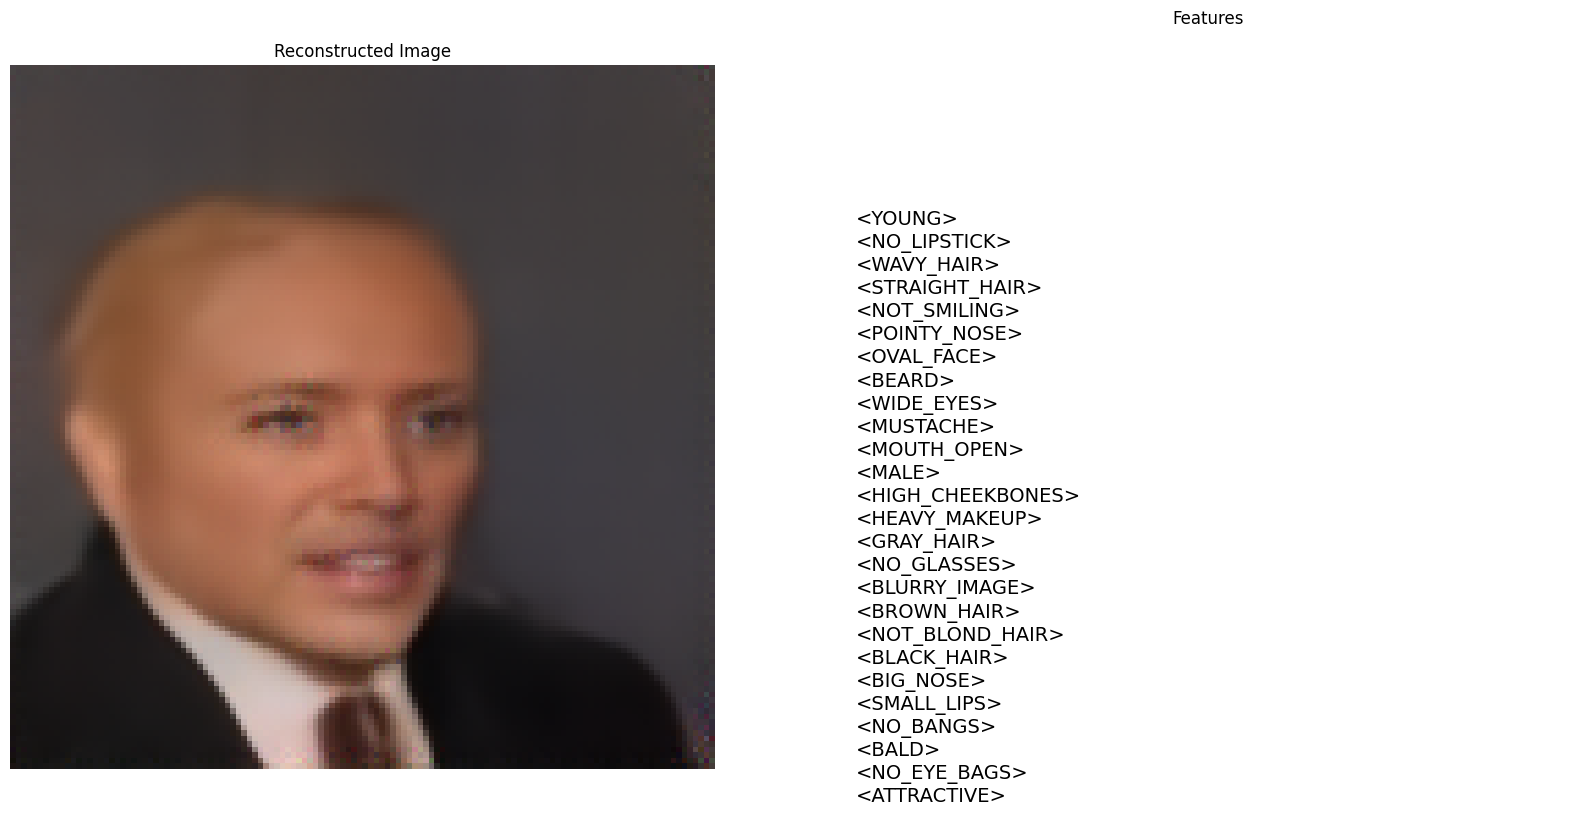

In [73]:
generate(fake_face_features())

Sequence Out:
<START_FACE> <ATTRACTIVE> <NO_EYE_BAGS> <BALD> <BANGS> <BIG_LIPS> <BIG_NOSE> <BLACK_HAIR> <NOT_BLOND_HAIR> <BROWN_HAIR> <CLEAR_IMAGE> <NO_GLASSES> <GRAY_HAIR> <HEAVY_MAKEUP> <LOW_CHEEKBONES> <FEMALE> <MOUTH_OPEN> <NO_MUSTACHE> <WIDE_EYES> <BEARD> <NON_OVAL_FACE> <ROUND_NOSE> <NOT_SMILING> <STRAIGHT_HAIR> <NOT_WAVY_HAIR> <LIPSTICK> <YOUNG> <START_GENERATION> <CODE_192> <CODE_031> <CODE_031> <CODE_031> <CODE_025> <CODE_190> <CODE_192> <CODE_031> <CODE_031> <CODE_192> <CODE_192> <CODE_192> <CODE_031> <CODE_031> <CODE_031> <CODE_192> <CODE_031> <CODE_190> <CODE_346> <CODE_190> <CODE_079> <CODE_283> <CODE_067> <CODE_283> <CODE_067> <CODE_031> <CODE_025> <CODE_025> <CODE_025> <CODE_025> <CODE_025> <CODE_192> <CODE_190> <CODE_358> <CODE_031> <CODE_161> <CODE_051> <CODE_264> <CODE_035> <CODE_455> <CODE_438> <CODE_496> <CODE_067> <CODE_025> <CODE_190> <CODE_031> <CODE_190> <CODE_031> <CODE_190> <CODE_208> <CODE_258> <CODE_205> <CODE_377> <CODE_457> <CODE_283> <CODE_496> <CODE_457>

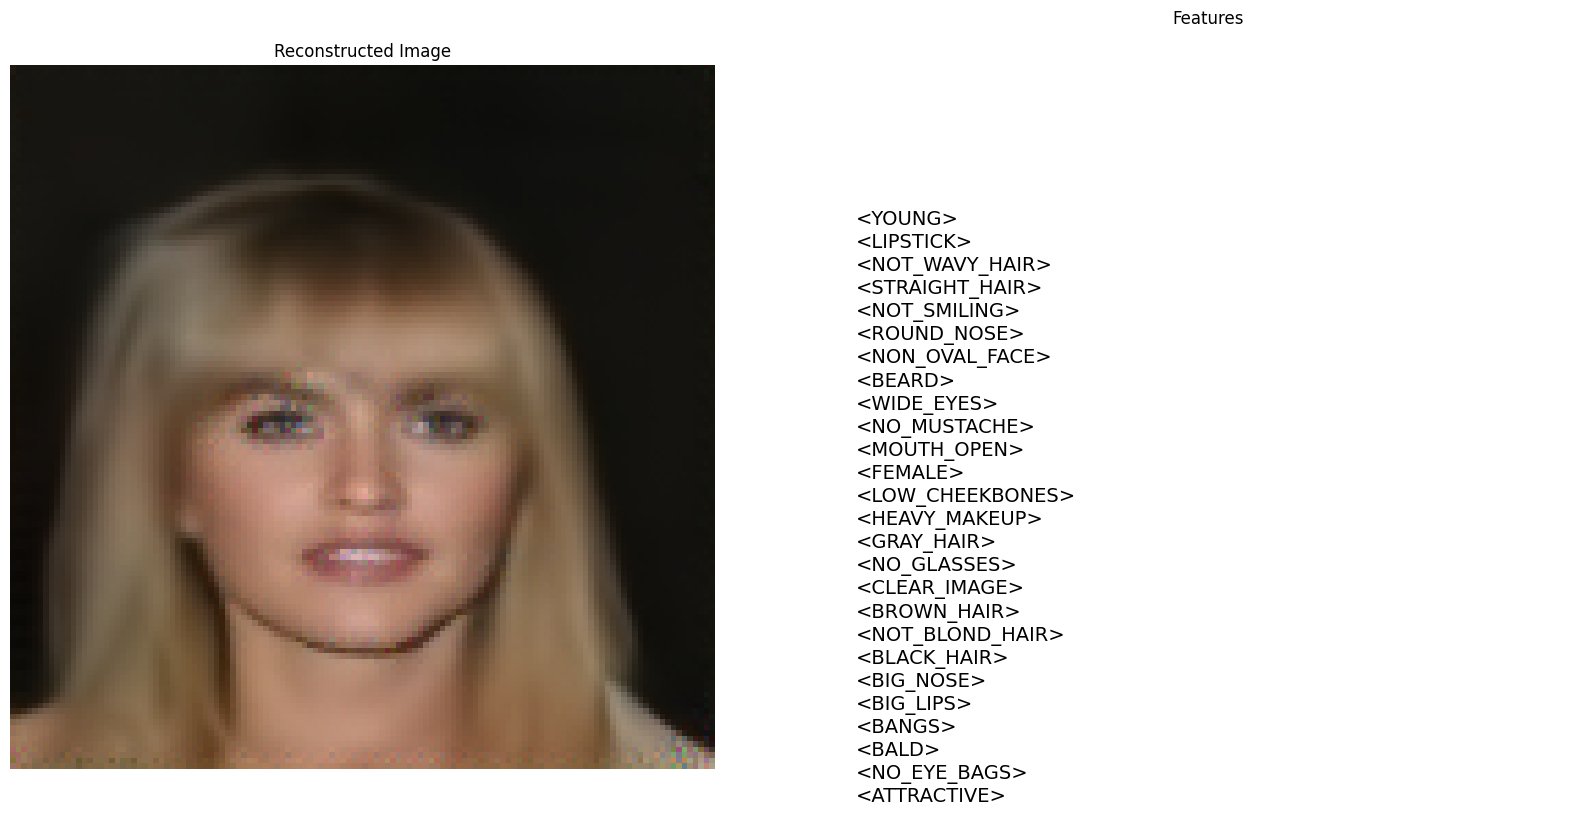

In [74]:
generate(fake_face_features())

Sequence Out:
<START_FACE> <NOT_ATTRACTIVE> <EYE_BAGS> <BALD> <BANGS> <SMALL_LIPS> <SMALL_NOSE> <NOT_BLACK_HAIR> <NOT_BLOND_HAIR> <BROWN_HAIR> <CLEAR_IMAGE> <NO_GLASSES> <GRAY_HAIR> <LIGHT_MAKEUP> <LOW_CHEEKBONES> <FEMALE> <MOUTH_OPEN> <NO_MUSTACHE> <NARROW_EYES> <NO_BEARD> <OVAL_FACE> <POINTY_NOSE> <SMILING> <NOT_STRAIGHT_HAIR> <WAVY_HAIR> <LIPSTICK> <YOUNG> <START_GENERATION> <CODE_192> <CODE_283> <CODE_192> <CODE_283> <CODE_488> <CODE_208> <CODE_208> <CODE_031> <CODE_488> <CODE_067> <CODE_192> <CODE_192> <CODE_067> <CODE_192> <CODE_067> <CODE_488> <CODE_192> <CODE_232> <CODE_283> <CODE_025> <CODE_417> <CODE_208> <CODE_208> <CODE_232> <CODE_192> <CODE_283> <CODE_283> <CODE_192> <CODE_283> <CODE_283> <CODE_283> <CODE_192> <CODE_283> <CODE_025> <CODE_192> <CODE_031> <CODE_067> <CODE_208> <CODE_208> <CODE_488> <CODE_417> <CODE_417> <CODE_488> <CODE_031> <CODE_283> <CODE_208> <CODE_208> <CODE_192> <CODE_192> <CODE_283> <CODE_208> <CODE_025> <CODE_417> <CODE_027> <CODE_095> <CODE_384> <CO

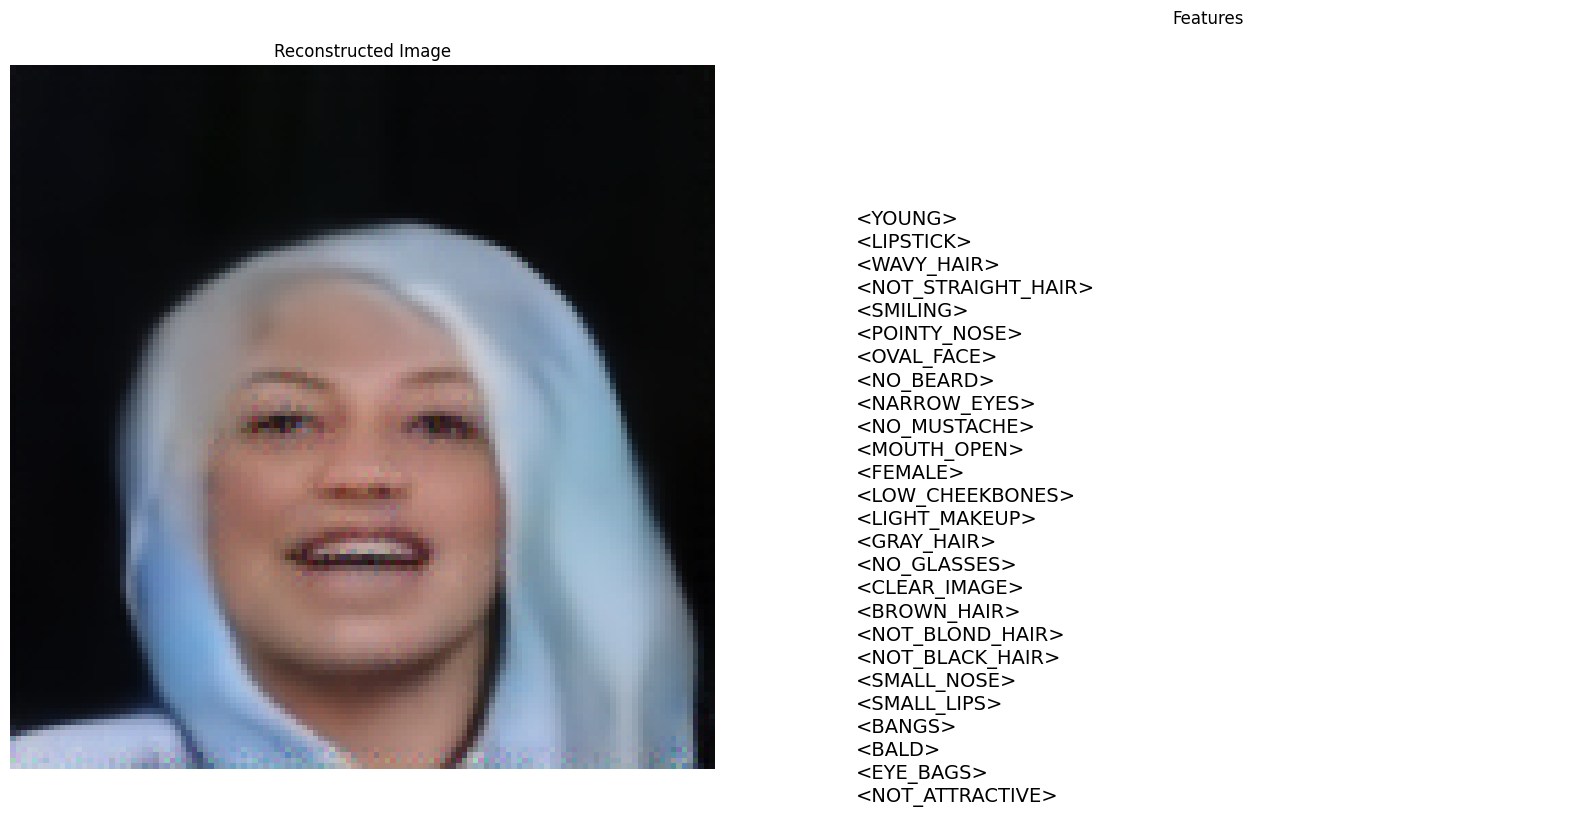

In [75]:
generate(fake_face_features())

# Push to HF

In [76]:
trainer.push_to_hub()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/yosef-samy019/gpt-face-celeb-generator/commit/eead2d39fa75b1104714bb77f7fddff194817416', commit_message='End of training', commit_description='', oid='eead2d39fa75b1104714bb77f7fddff194817416', pr_url=None, repo_url=RepoUrl('https://huggingface.co/yosef-samy019/gpt-face-celeb-generator', endpoint='https://huggingface.co', repo_type='model', repo_id='yosef-samy019/gpt-face-celeb-generator'), pr_revision=None, pr_num=None)

In [77]:
tokenizer.push_to_hub("yosef-samy019/gpt-face-celeb-generator")

README.md: 0.00B [00:00, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/yosef-samy019/gpt-face-celeb-generator/commit/eead2d39fa75b1104714bb77f7fddff194817416', commit_message='Upload tokenizer', commit_description='', oid='eead2d39fa75b1104714bb77f7fddff194817416', pr_url=None, repo_url=RepoUrl('https://huggingface.co/yosef-samy019/gpt-face-celeb-generator', endpoint='https://huggingface.co', repo_type='model', repo_id='yosef-samy019/gpt-face-celeb-generator'), pr_revision=None, pr_num=None)